# インド株 ファクター検証 — Step 15: 合成スコア（ロングオンリー・ティルト）

## 仕様（ユーザー決定 2026-09）

| 項目 | 決定 |
|---|---|
| 目的 | **ロングオンリー・ティルト**。主指標 = Q5 の対ベンチ超過・TE・IR（EW） |
| スリーブ A: リビジョン | `rev1p, rev1r, rev3p, rev3r`（core のみ、gdb 除外） |
| スリーブ B: 価格系 | `mom12_1` + **gain 側条件付き `cgo_60m`**（含み益銘柄のみランク、損側は欠損扱い） |
| スリーブ C: AI | **一旦除外** |
| スリーブ D: 規律 | `doe, npop, dp_act` ＋ 負符号で `xfin_sp, xfin_cf, ta_grw` |
| ウェイト | **ベースライン = スリーブ等ウェイト**（2段: スリーブ内等W → スリーブ間等W）。比較: 全ファクター等W / 過去ICIR加重（PIT） |
| スコア規約 | size+sector 中立 Blom → スリーブ内 skipna 平均 → 再Blom → スリーブ間合成 → 再Blom |
| 欠損 | 利用可能な素材のみで平均（`docs/tutorial` 2.6 の再ウェイト）。B の損側銘柄は mom12_1 のみで構成される |
| 期間 | 200801〜202607。IS 2008–2018 / OOS 2019– を併記 |

## スリーブ D の素材の意味（定義ファイルは空欄のため標準定義 + 検証済みエビデンス）

| 素材 | 意味 | 採用根拠（当プロジェクトの検証） |
|---|---|---|
| `doe` | **Dividend on Equity** = 配当総額 ÷ 自己資本（= 配当性向 × ROE）。自己資本をどれだけ現金で株主に返しているか | L/S +7.1% (t 2.2)。**srtn（BARRA控除後）でも t 2.3〜3.7**（Step 13 の生き残り） |
| `npop` | **Net Payout (5Y) / Operating Income (5Y)**（定義ファイル記載あり）。5年累計の純還元（配当+自社株買い−発行）÷ 5年累計営業利益。稼いだ営業利益のうち株主に返した割合 | L/S +4.3%。還元の「持続性」を捉える5年版 |
| `dp_act` | 実績配当利回り（実績 DPS ÷ 株価）。バリュエーション込みの還元 | L/S +10.5% (t 3.6)、中立後も Q5 有意 |
| `xfin_sp` / `xfin_cf` | **外部ファイナンス**（Bradshaw-Richardson-Sloan 型）: 株式・負債の純調達額。`_cf` = CF計算書ベース、`_sp` = 売上比とみられる（正確な分母は定義書欠落）。**高い = 外部資金依存・希薄化 → 負符号で採用** | L/S −8.8% / −7.6%（有意、**中立化後も生存**した最強の負シグナル群） |
| `ta_grw` | 総資産成長率（YoY）。Cooper-Gulen-Schill 型の資産成長アノマリー。**負符号で採用** | Step 14: **srtn FM t −3.4**。高収益条件でも符号は反転しない（無条件に負）ことを確認済み |

D の設計思想: 「現金を株主に返している」(+doe, npop, dp_act) × 「外部資金と資産膨張に頼っていない」(−xfin, −ta_grw)。
Step 13/14 の結論に従い**交差項は使わず主効果のみ**。

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import factorlab as fl

fl.plotting.set_style()
pd.set_option("display.width", 260, "display.max_columns", 40, "display.float_format", lambda v: f"{v:,.4f}")

START, END = 200801, 202607
OOS_SPLIT = 201901
Q = 5
FIGDIR = "15_composite"

SLEEVES = {
    "A_revision": [("rev1p", +1), ("rev1r", +1), ("rev3p", +1), ("rev3r", +1)],
    "B_price": [("mom12_1", +1), ("cgo_gain", +1)],
    "D_discipline": [("doe", +1), ("npop", +1), ("dp_act", +1),
                     ("xfin_sp", -1), ("xfin_cf", -1), ("ta_grw", -1)],
}
CORE_FACTORS = ["rev1p", "rev1r", "rev3p", "rev3r", "mom12_1",
                "doe", "npop", "dp_act", "xfin_sp", "xfin_cf", "ta_grw"]

## 1. パネルとスコア構築

In [2]:
panel = fl.data.build_panel(CORE_FACTORS, start=START, end=END)
cgo = fl.cgo.load_cgo_monthly(["cgo_60m"], start=START, end=END)["cgo_60m"].reindex(panel.index)
panel["cgo_gain"] = cgo.where(cgo > 0)   # gain 側条件付き（損側は NaN → B は mom のみで構成）

ALL = CORE_FACTORS + ["cgo_gain"]
panel = fl.preprocess.standardize_panel(panel, ALL, method="blom",
                                        group_col="sector", control_cols=["log_cap"],
                                        suffix="_ss")

# スリーブスコア: 符号調整 → skipna 平均 → 再Blom
for sl, members in SLEEVES.items():
    mat = pd.concat({f: sgn * panel[f"{f}_ss"] for f, sgn in members}, axis=1)
    panel[f"__{sl}"] = mat.mean(axis=1, skipna=True)
    panel = fl.preprocess.standardize_panel(panel, f"__{sl}", method="blom", suffix="_b")
    panel[sl] = panel[f"__{sl}_b"]
    panel = panel.drop(columns=[f"__{sl}", f"__{sl}_b"])

fl.altdata.score_characteristics(panel, list(SLEEVES))[
    ["n_stocks_mean", "coverage_univ", "coverage_bench", "rank_autocorr"]]

,n_stocks_mean,coverage_univ,coverage_bench,rank_autocorr
A_revision,337.4619,0.9063,0.9902,0.5599
B_price,375.0179,0.9990,0.9996,0.8727
D_discipline,375.2511,0.9997,1.0000,0.9667


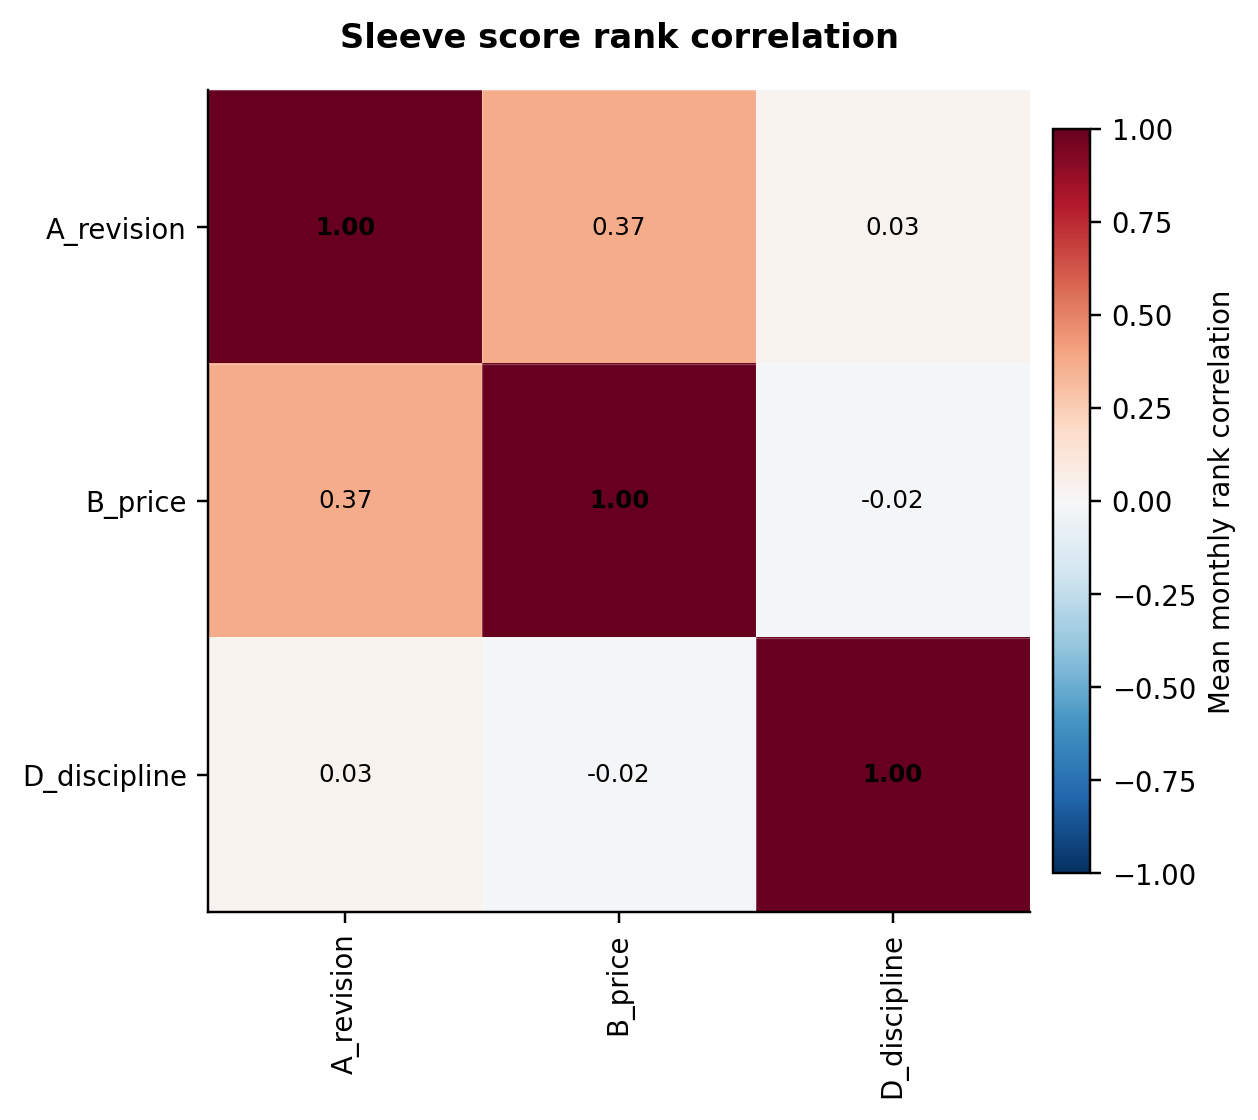

In [3]:
corr = fl.multi.cross_sectional_corr(panel, list(SLEEVES), labels=list(SLEEVES))
fig = fl.plotting.plot_factor_matrix(
    corr, title="Sleeve score rank correlation",
    off_label="Mean monthly rank correlation", off_vmin=-1, off_vmax=1,
    annotate=True, figsize=(6.4, 5.2), band=0.0)
fl.plotting.savefig(fig, f"{FIGDIR}/100_sleeve_corr");

## 2. 合成（3方式）

- `comp_ew`   : スリーブ等ウェイト（**ベースライン**）
- `comp_flat` : 全12ファクター等ウェイト（符号調整後）
- `comp_icir` : スリーブ間を過去 ICIR 加重（PIT: 時点 t のウェイトは t−1 月までの
  実績のみで計算。expanding、最低36ヶ月、それ未満とマイナス ICIR は等W/ゼロ）

In [4]:
# (1) スリーブ等W
panel["__c"] = panel[list(SLEEVES)].mean(axis=1, skipna=True)
panel = fl.preprocess.standardize_panel(panel, "__c", method="blom", suffix="_b")
panel["comp_ew"] = panel["__c_b"]; panel = panel.drop(columns=["__c", "__c_b"])

# (2) 全ファクター等W
mat = pd.concat({f: sgn * panel[f"{f}_ss"] for sl, ms in SLEEVES.items() for f, sgn in ms}, axis=1)
panel["__c"] = mat.mean(axis=1, skipna=True)
panel = fl.preprocess.standardize_panel(panel, "__c", method="blom", suffix="_b")
panel["comp_flat"] = panel["__c_b"]; panel = panel.drop(columns=["__c", "__c_b"])

# (3) 過去ICIR加重（PIT）
ics = {sl: fl.ic.information_coefficient(panel, sl, "fwd_rtn") for sl in SLEEVES}
ic_df = pd.DataFrame(ics)
yms = sorted(panel.index.get_level_values("yyyymm").unique())
w_rows = {}
for t in yms:
    hist = ic_df[ic_df.index < t].dropna(how="all")   # 時点 t で実現済みの IC のみ
    if len(hist) < 36:
        w = pd.Series(1.0, index=list(SLEEVES))
    else:
        icir = hist.mean() / hist.std(ddof=1)
        w = icir.clip(lower=0.0)
        if w.sum() == 0:
            w = pd.Series(1.0, index=list(SLEEVES))
    w_rows[t] = w / w.sum()
W = pd.DataFrame(w_rows).T

pieces = []
for t in yms:
    blk = panel.xs(t, level="yyyymm", drop_level=False)[list(SLEEVES)]
    wt = W.loc[t]
    avail = blk.notna()
    num = (blk.fillna(0) * wt).sum(axis=1)
    den = (avail * wt).sum(axis=1)
    pieces.append(num / den.replace(0, np.nan))
panel["__c"] = pd.concat(pieces).reindex(panel.index)
panel = fl.preprocess.standardize_panel(panel, "__c", method="blom", suffix="_b")
panel["comp_icir"] = panel["__c_b"]; panel = panel.drop(columns=["__c", "__c_b"])

print("ICIR ウェイトの推移（年末値）:")
W.loc[[y for y in W.index if y % 100 == 12]].iloc[::3].round(3)

ICIR ウェイトの推移（年末値）:


,A_revision,B_price,D_discipline
200812,0.3330,0.3330,0.3330
201112,0.3350,0.1380,0.5270
201412,0.3460,0.1580,0.4960
201712,0.3500,0.1900,0.4600
202012,0.3580,0.2220,0.4200
202312,0.3600,0.2260,0.4140


## 3. 評価（主指標: Q5 の対ベンチ超過、EW）

In [5]:
CANDS = ["comp_ew", "comp_flat", "comp_icir"] + list(SLEEVES) + ["rev3p_ss"]
res, summ = {}, {}
for c in CANDS:
    res[c] = fl.quantile.quantile_returns(panel, c, q=Q, ascending=True)
    summ[c] = fl.quantile.quantile_summary(res[c], weighting="ew")

rows = {}
for c in CANDS:
    s = summ[c]
    ic = fl.ic.ic_summary(fl.ic.information_coefficient(panel, c, "fwd_rtn"))
    rows[c] = {
        "top_ann_excess": s.loc[f"Q{Q}", "ann_excess"], "top_te": s.loc[f"Q{Q}", "te"],
        "top_IR": s.loc[f"Q{Q}", "IR"], "top_t_NW": s.loc[f"Q{Q}", "t_stat_NW"],
        "top_max_dd_x": s.loc[f"Q{Q}", "max_dd_excess"],
        "top_turnover_ann": s.loc[f"Q{Q}", "turnover_ann"],
        "ls_ann_excess": s.loc[f"Q{Q}-Q1", "ann_excess"], "ls_t_NW": s.loc[f"Q{Q}-Q1", "t_stat_NW"],
        "mean_IC": ic["mean_IC"], "ICIR_ann": ic["ICIR_ann"],
    }
pd.DataFrame(rows).T

,top_ann_excess,top_te,top_IR,top_t_NW,top_max_dd_x,top_turnover_ann,ls_ann_excess,ls_t_NW,mean_IC,ICIR_ann
comp_ew,0.1190,0.0984,1.0762,5.2599,-0.1080,4.0461,0.1938,5.3143,0.0670,1.7114
comp_flat,0.1058,0.0945,1.0082,4.7565,-0.1082,4.1686,0.2013,6.4590,0.0646,1.9271
comp_icir,0.0973,0.0920,0.9451,4.5213,-0.1095,3.9331,0.1797,5.4145,0.0620,1.7713
A_revision,0.0927,0.0981,0.9311,3.9980,-0.1761,6.1832,0.1423,5.7877,0.0448,1.5622
B_price,0.0622,0.1092,0.5606,2.5130,-0.2896,3.1793,0.0909,2.4152,0.0462,1.0781
D_discipline,0.0521,0.0834,0.5782,2.5939,-0.1800,1.4122,0.1259,4.4701,0.0431,1.7452
rev3p_ss,0.0923,0.1100,0.8591,3.5509,-0.2247,4.2377,0.1394,4.6301,0.0489,1.4948


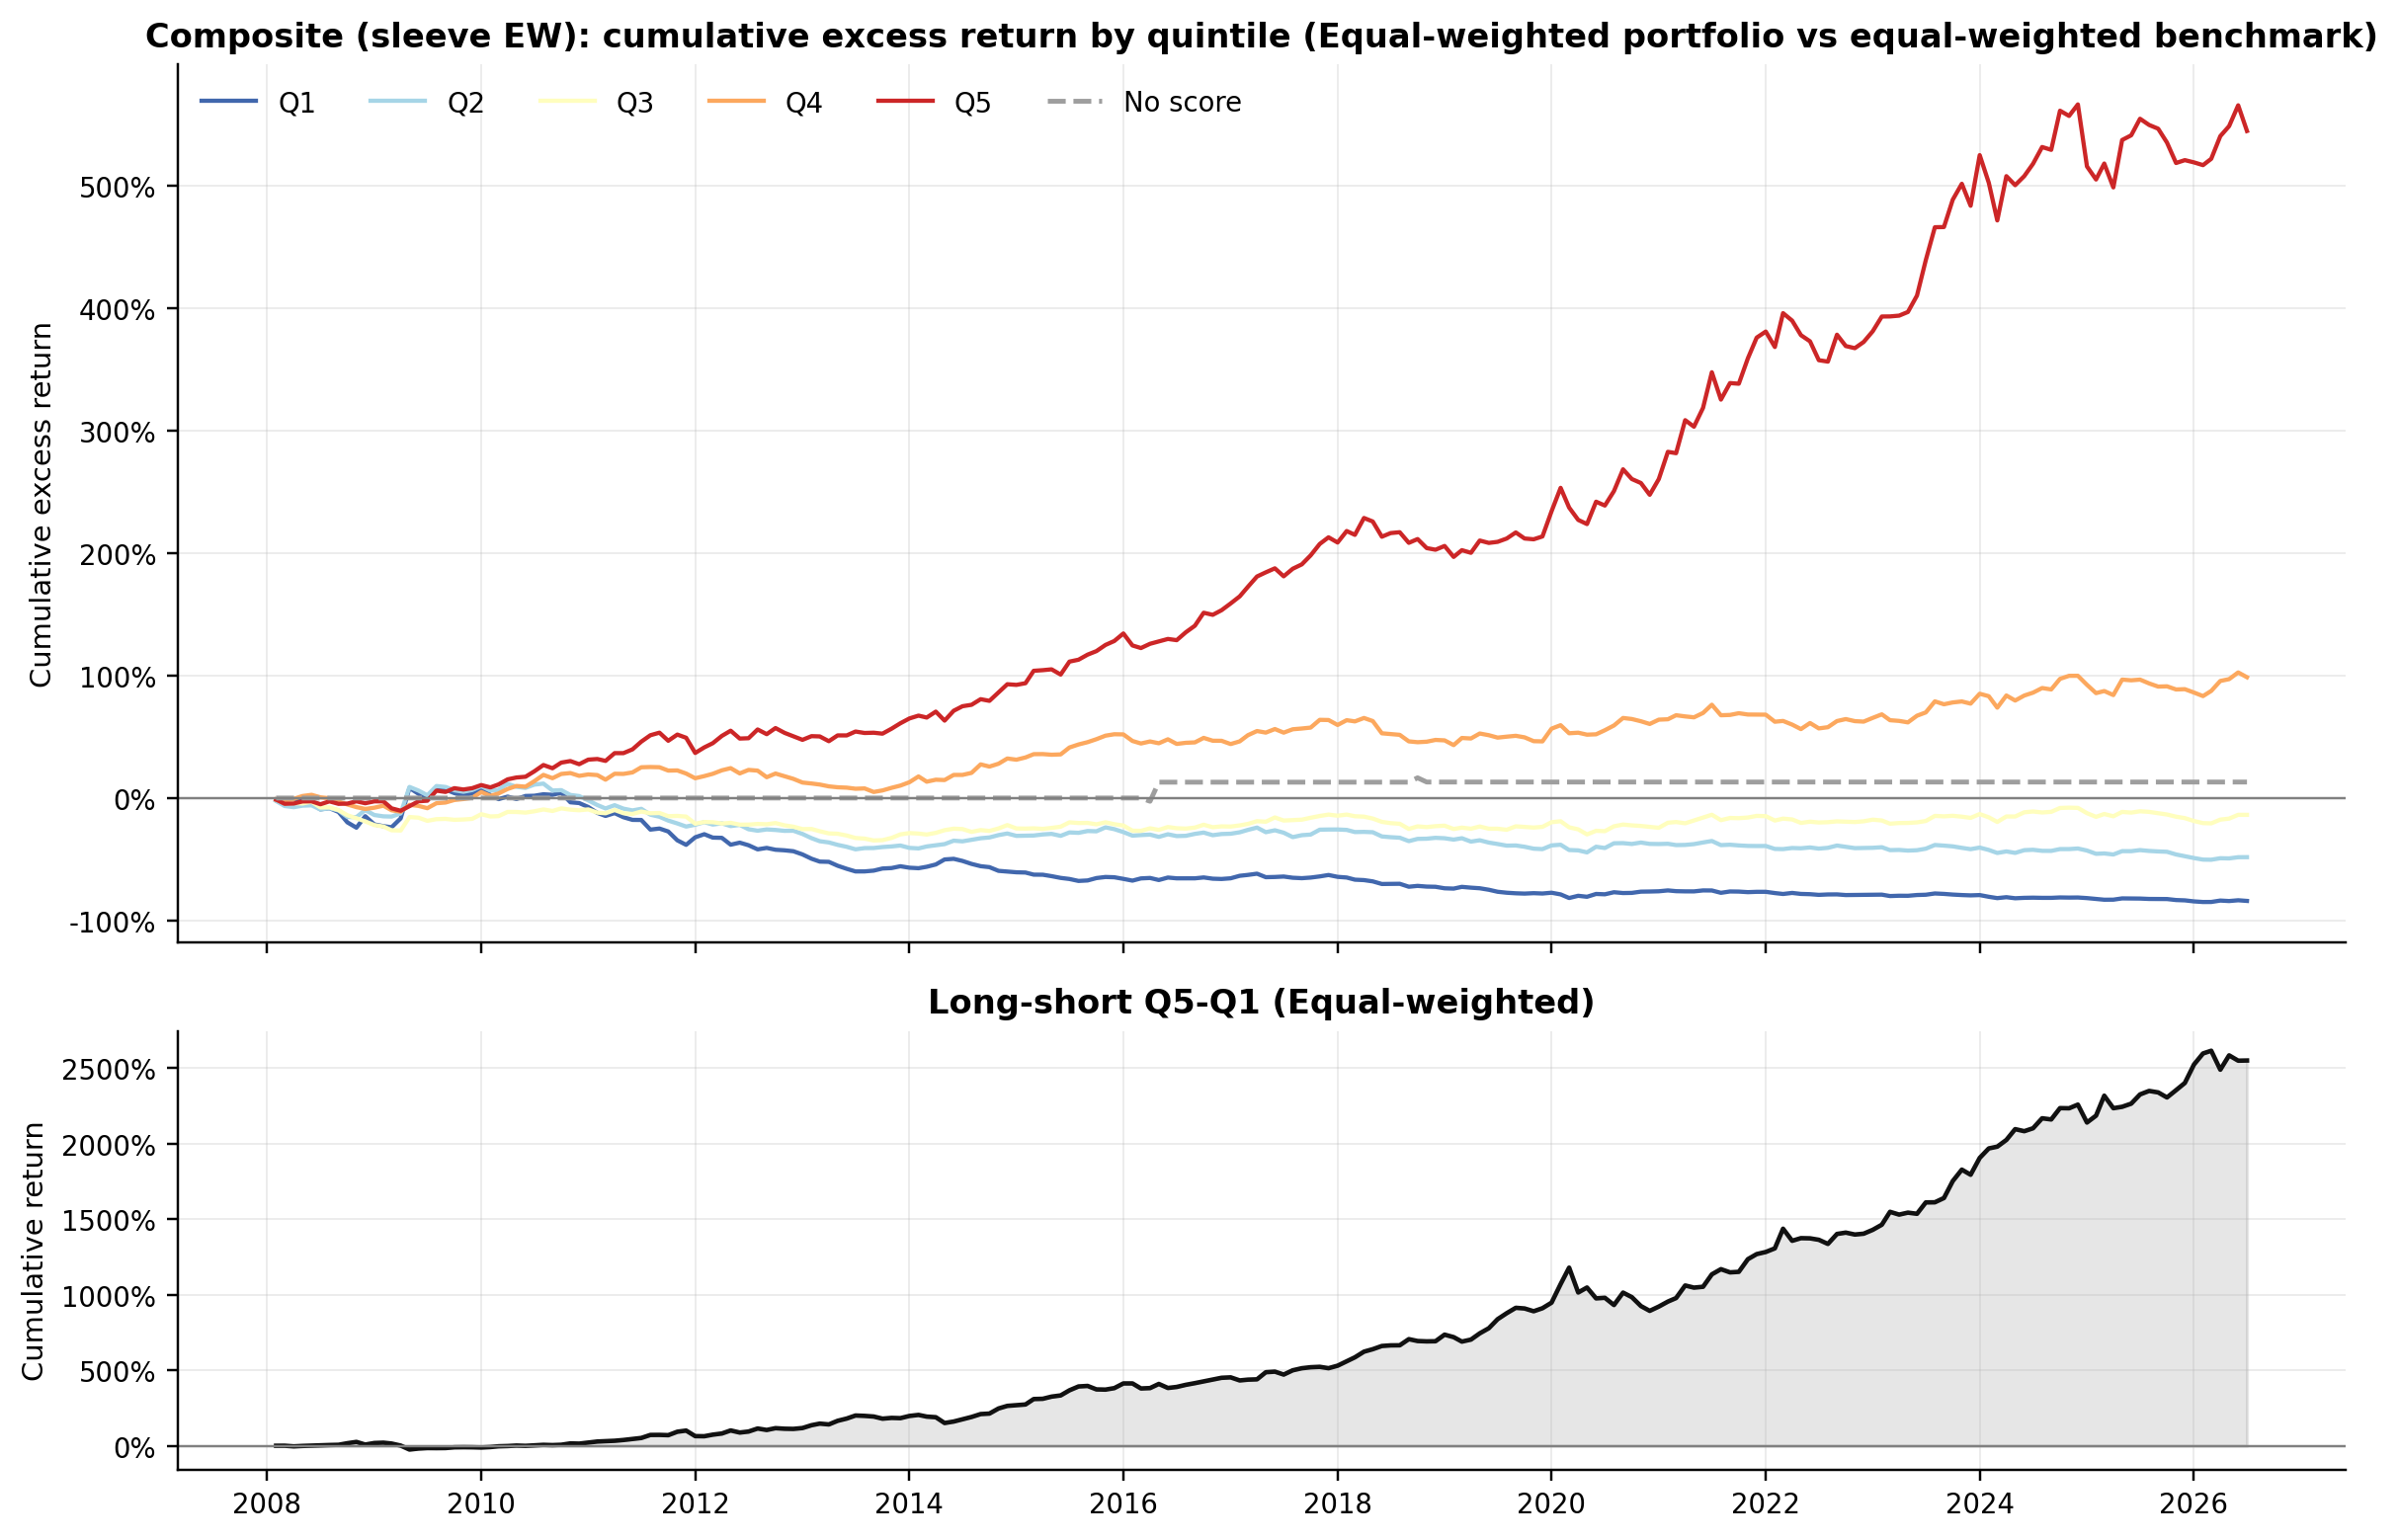

In [6]:
fig = fl.plotting.plot_quantile_timeseries(res["comp_ew"], weighting="ew", q=Q,
                                           factor="Composite (sleeve EW)", show_na=True)
fl.plotting.savefig(fig, f"{FIGDIR}/101_composite_ts");

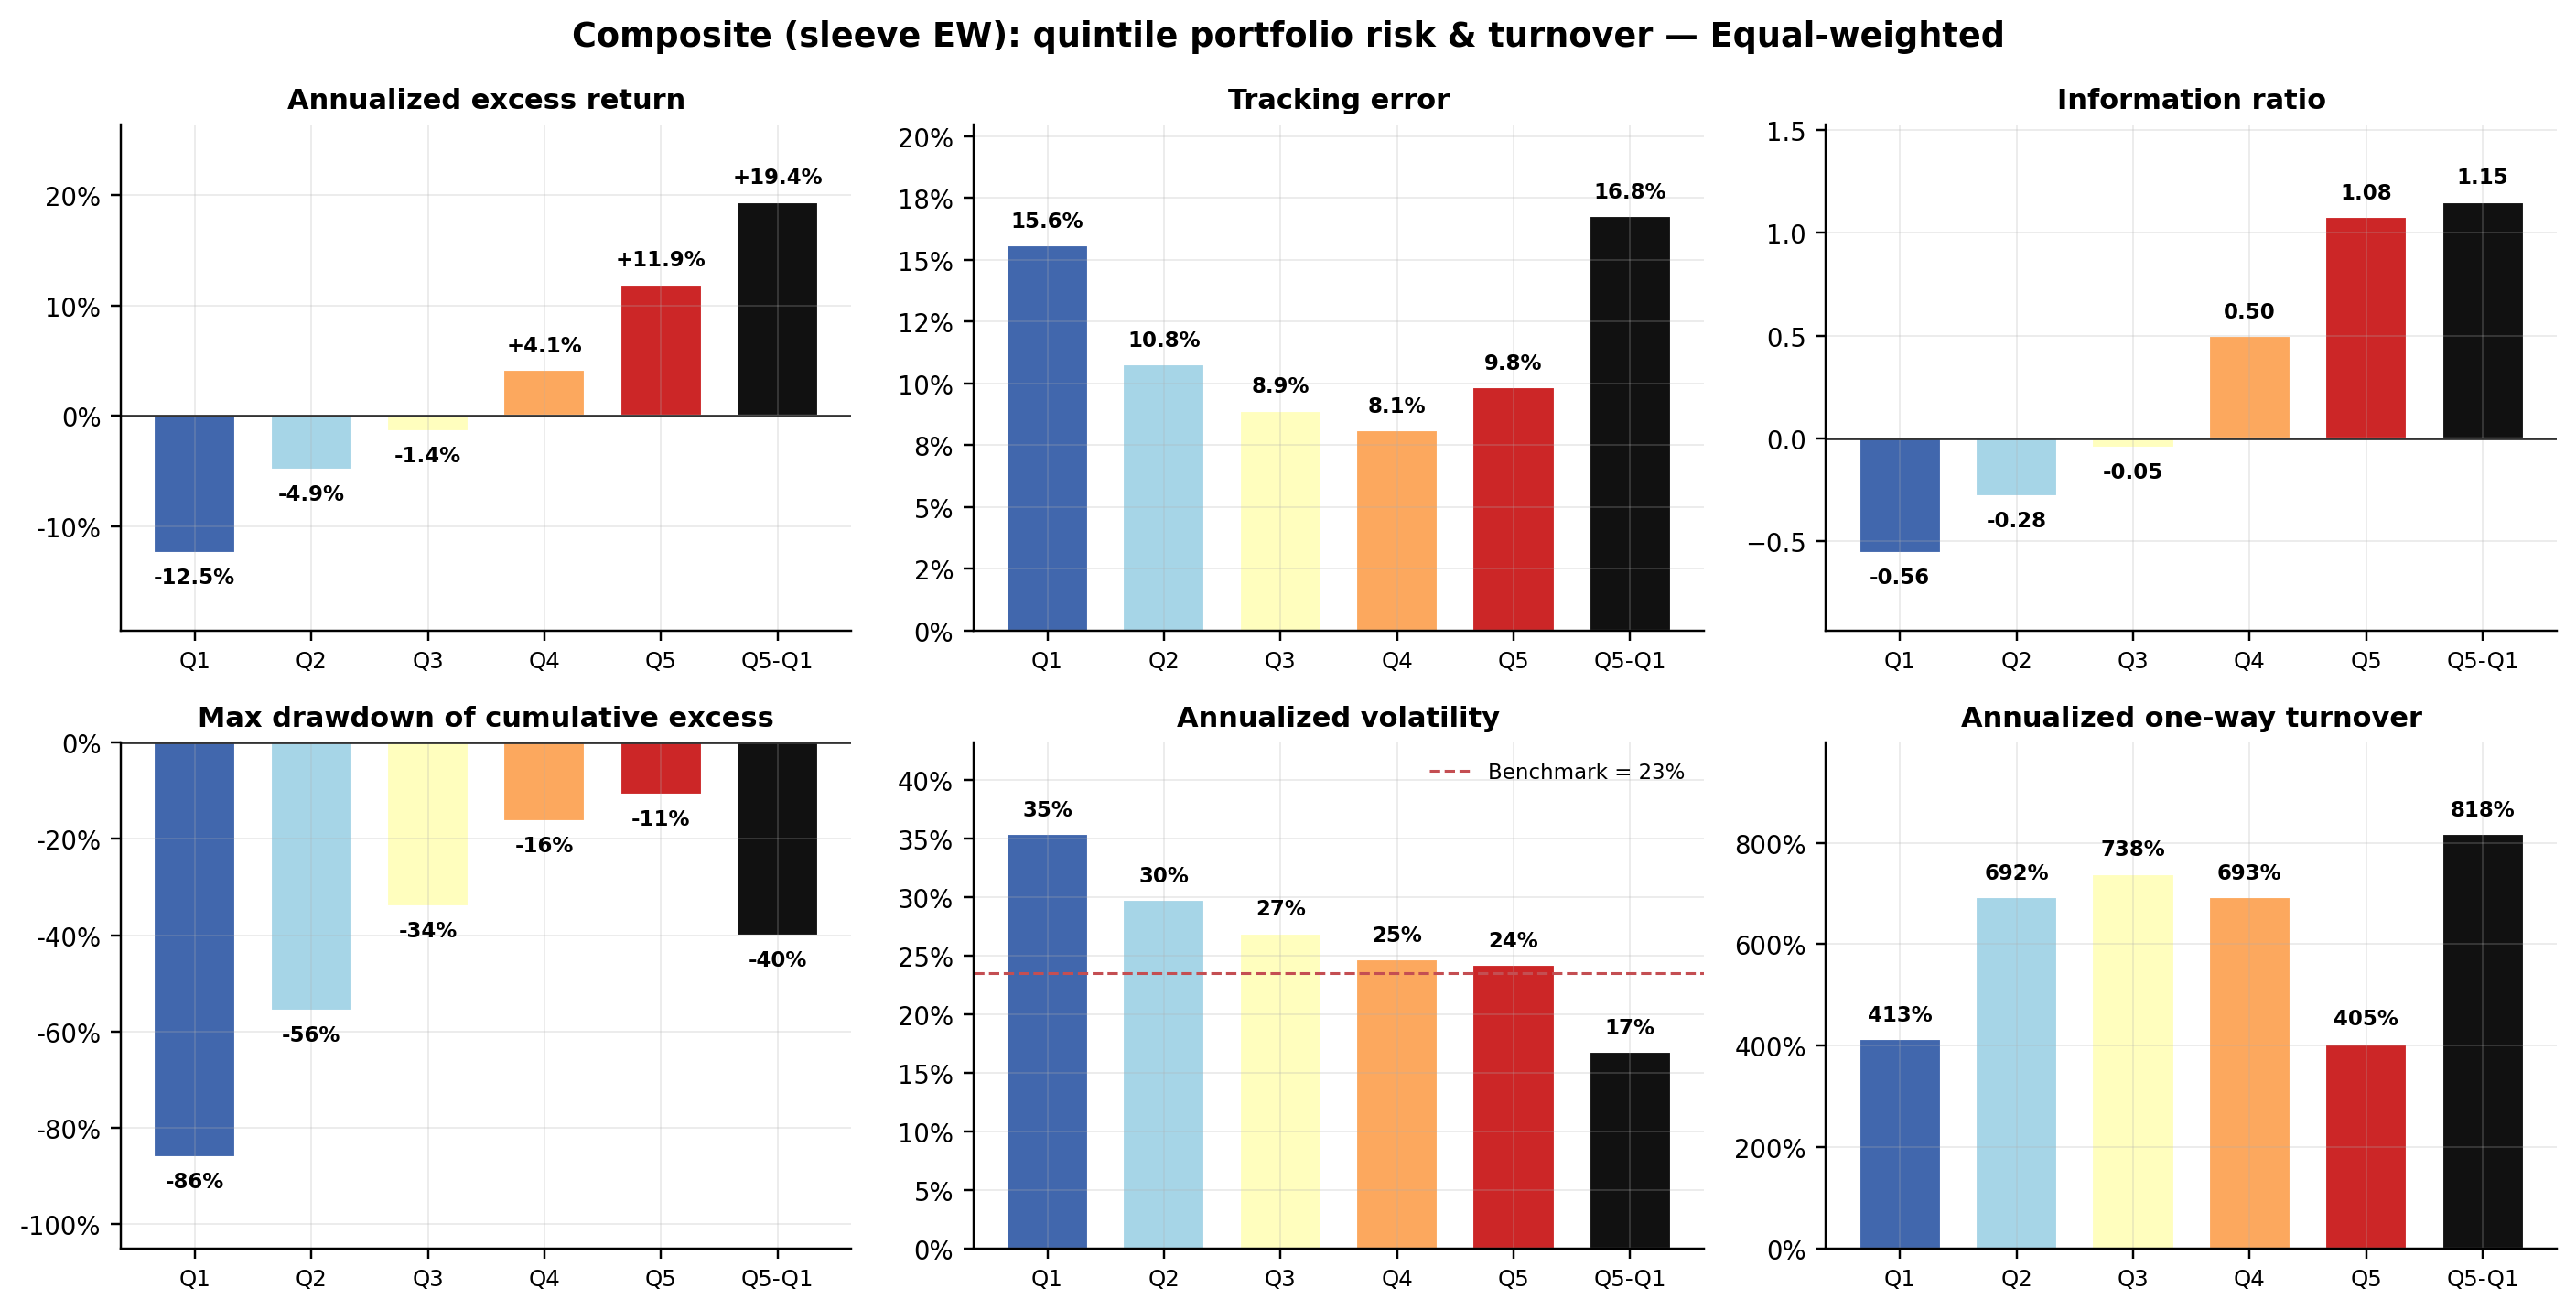

In [7]:
fig = fl.plotting.plot_quantile_dashboard(summ["comp_ew"], q=Q,
                                          factor="Composite (sleeve EW)", weighting="ew")
fl.plotting.savefig(fig, f"{FIGDIR}/102_composite_dashboard");

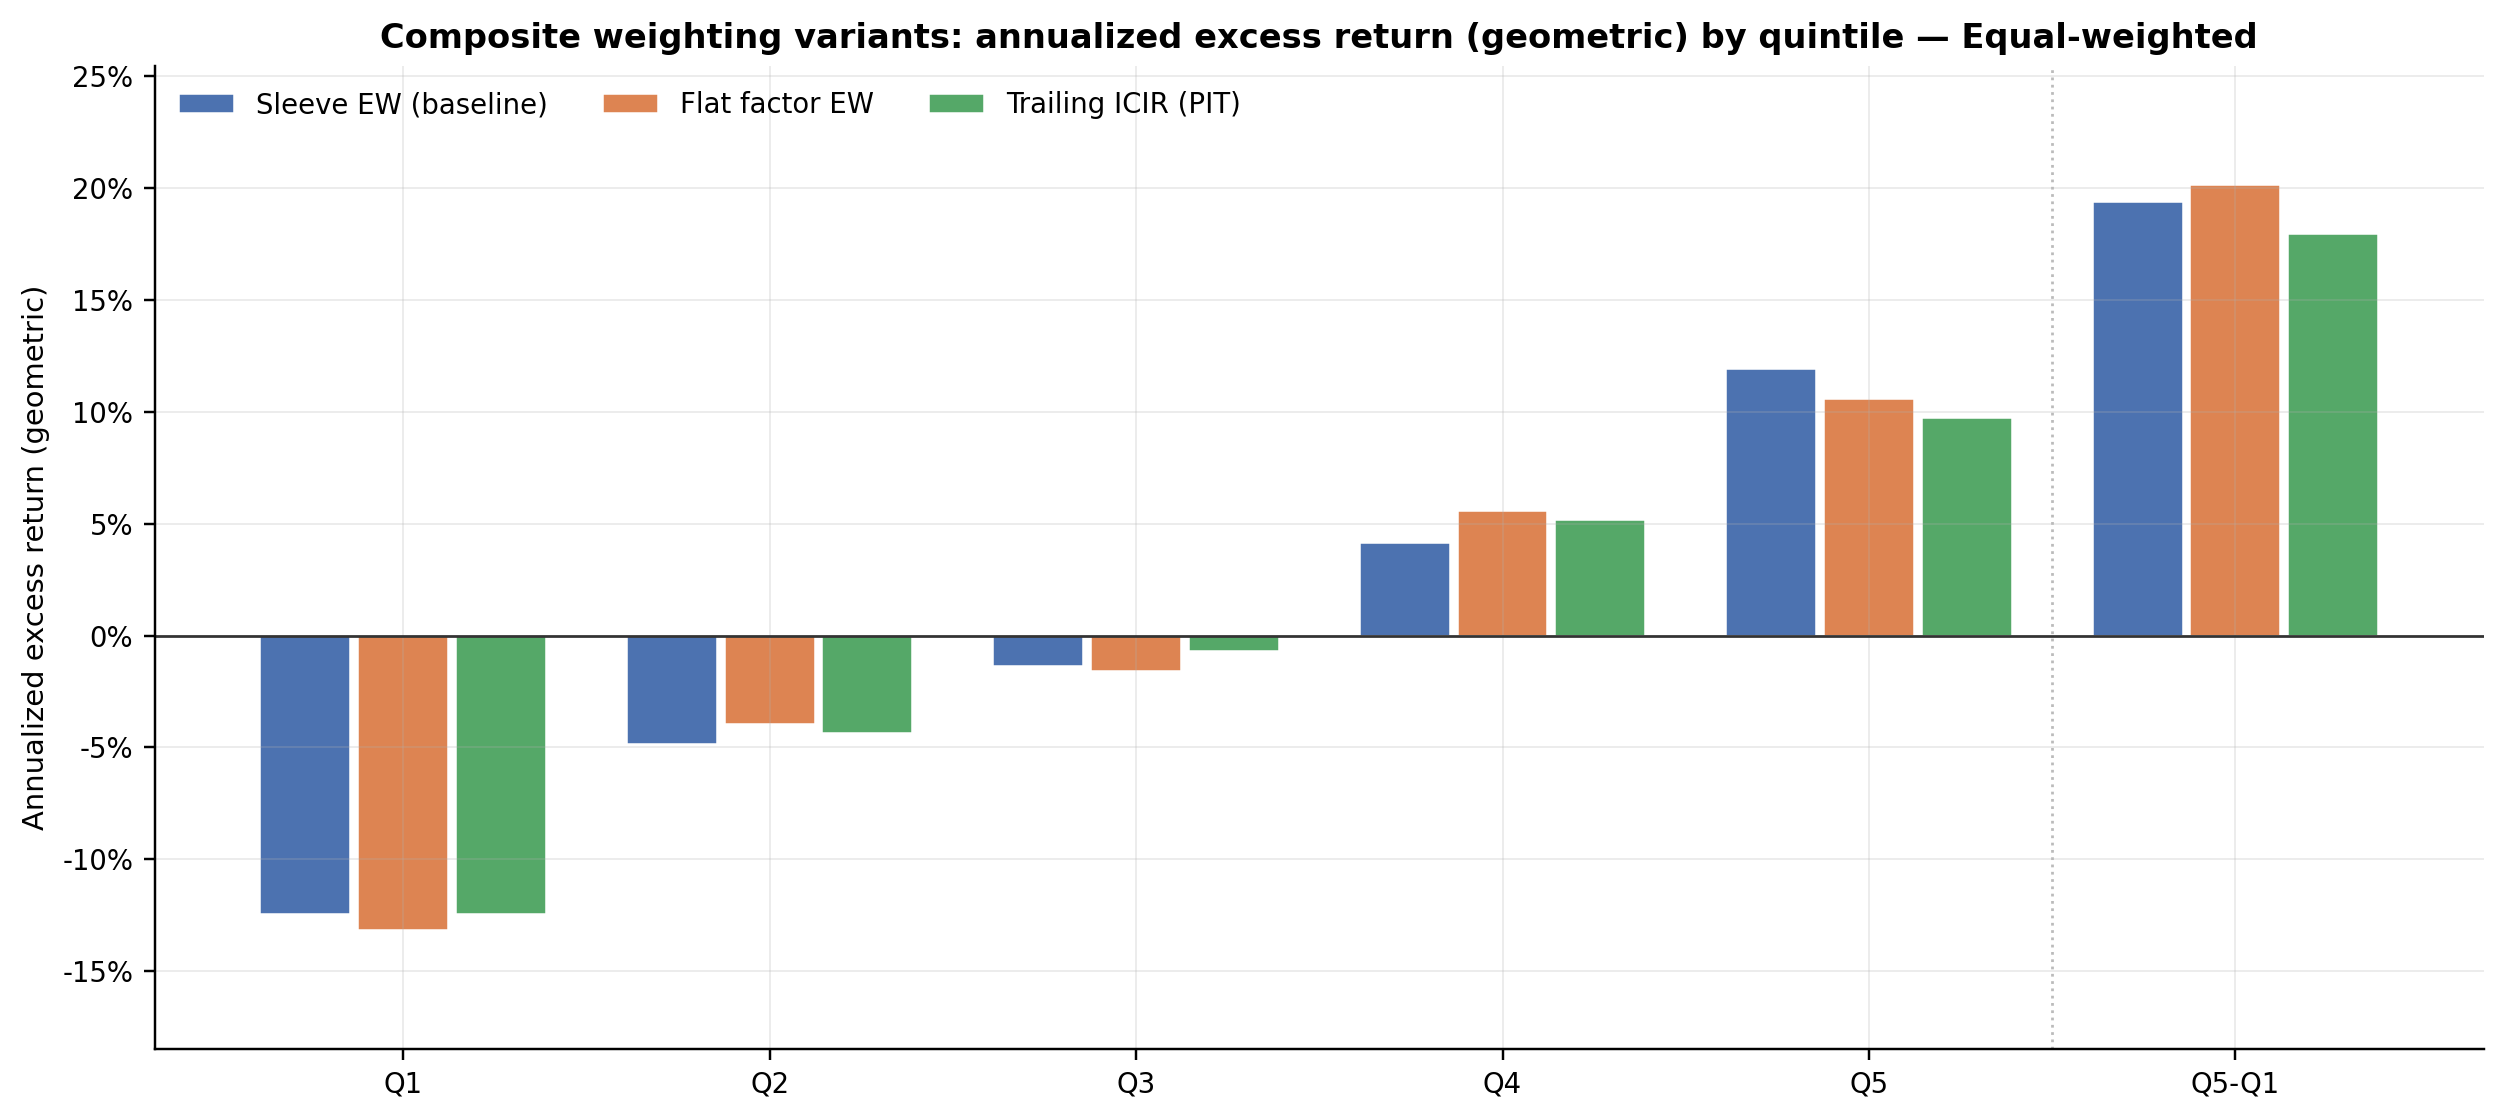

In [8]:
fig = fl.plotting.plot_variant_quantile_bar(
    {c: summ[c] for c in ["comp_ew", "comp_flat", "comp_icir"]}, q=Q,
    factor="Composite weighting variants", weighting="ew",
    labels={"comp_ew": "Sleeve EW (baseline)", "comp_flat": "Flat factor EW",
            "comp_icir": "Trailing ICIR (PIT)"})
fl.plotting.savefig(fig, f"{FIGDIR}/103_weighting_variants");

## 3.5 時価総額ウェイト版と IC 時系列（ベースライン comp_ew）

- CW = 分位内 時価総額ウェイト vs ベンチ時価総額ウェイト（キャパシティの検査）
- IC はクロスセクション順位相関なのでウェイトに依存しない（1本）

In [9]:
summ_cw = fl.quantile.quantile_summary(res["comp_ew"], weighting="cw")
print("=== comp_ew: EW vs CW（Q5 / Q5-Q1）===")
pd.concat({
    "EW": summ["comp_ew"].loc[[f"Q{Q}", f"Q{Q}-Q1"]],
    "CW": summ_cw.loc[[f"Q{Q}", f"Q{Q}-Q1"]],
}, names=["weighting", "bucket"])[
    ["ann_excess", "ann_excess_arith", "te", "IR", "t_stat_NW", "max_dd_excess", "turnover_ann"]]

=== comp_ew: EW vs CW（Q5 / Q5-Q1）===


ann_excess  ann_excess_arith     te     IR  t_stat_NW  max_dd_excess  turnover_ann
weighting bucket                                                                                    
EW        Q5          0.1190            0.1059 0.0984 1.0762     5.2599        -0.1080        4.0461
          Q5-Q1       0.1938            0.1930 0.1678 1.1503     5.3143        -0.4000        8.1761
CW        Q5          0.0865            0.0741 0.1023 0.7240     3.0624        -0.2466        4.5044
          Q5-Q1       0.0776            0.0968 0.2046 0.4730     1.8649        -0.5321        8.8543

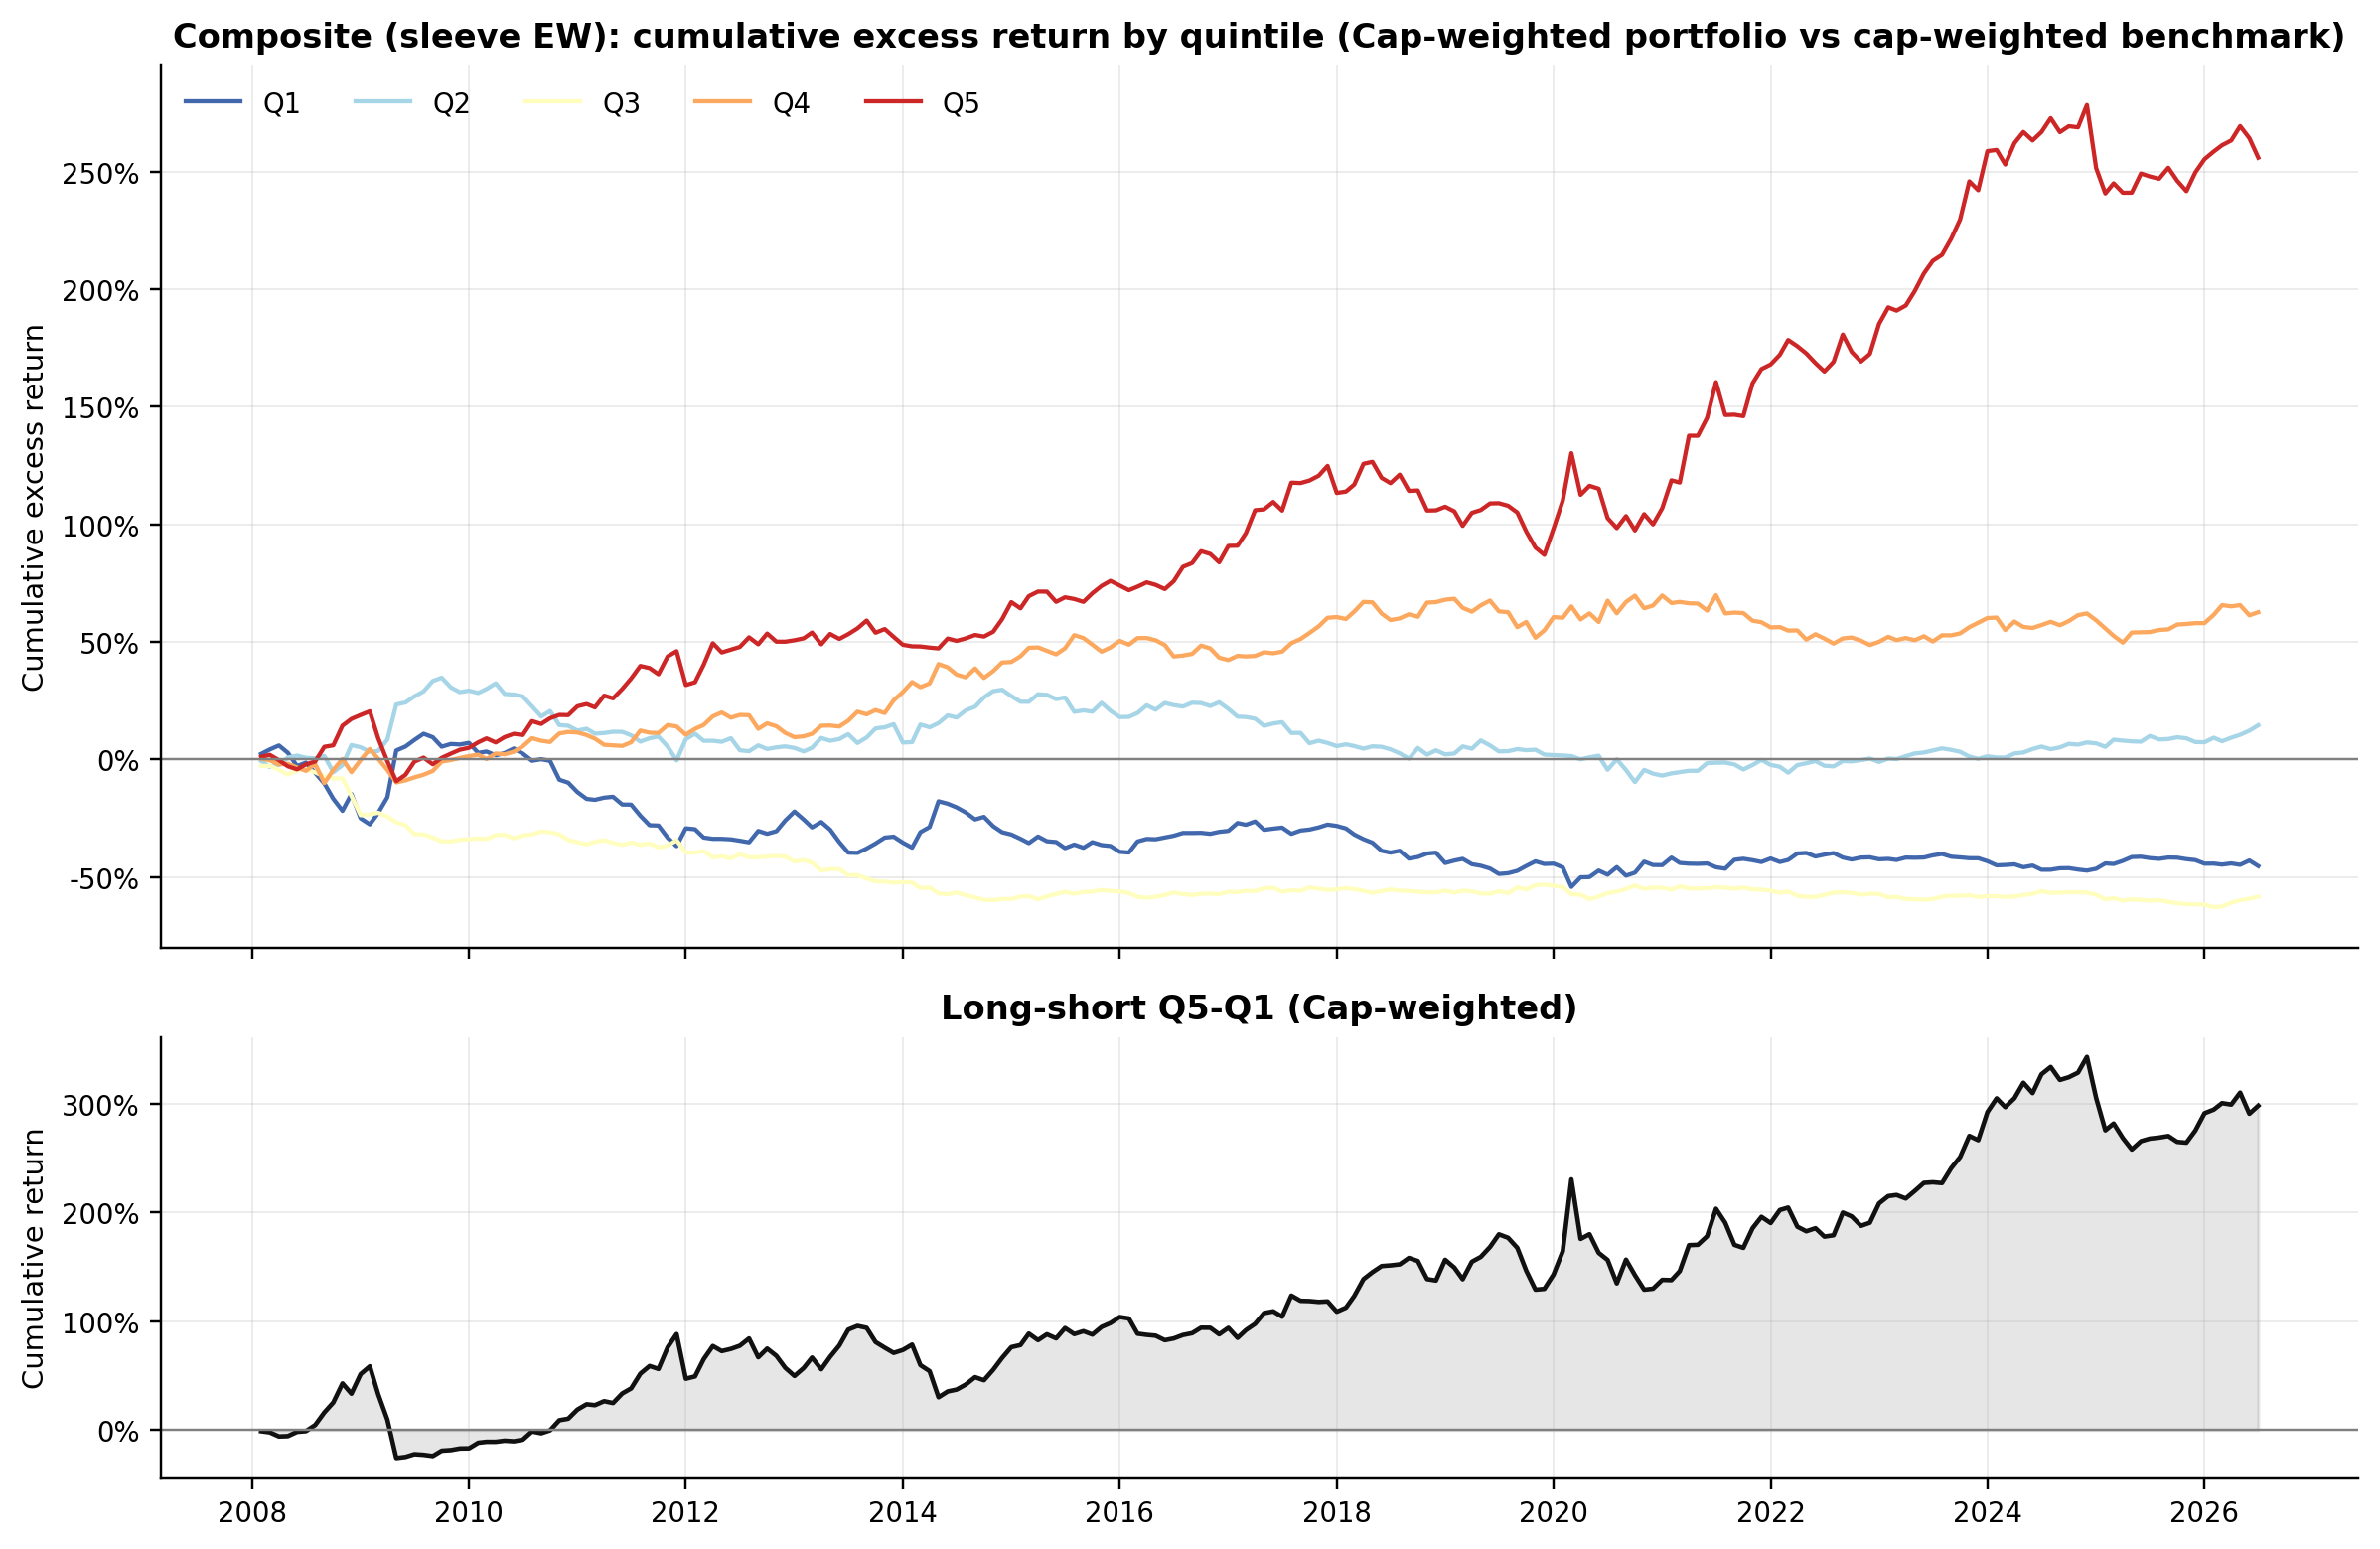

In [10]:
fig = fl.plotting.plot_quantile_timeseries(res["comp_ew"], weighting="cw", q=Q,
                                           factor="Composite (sleeve EW)")
fl.plotting.savefig(fig, f"{FIGDIR}/104_composite_ts_cw");

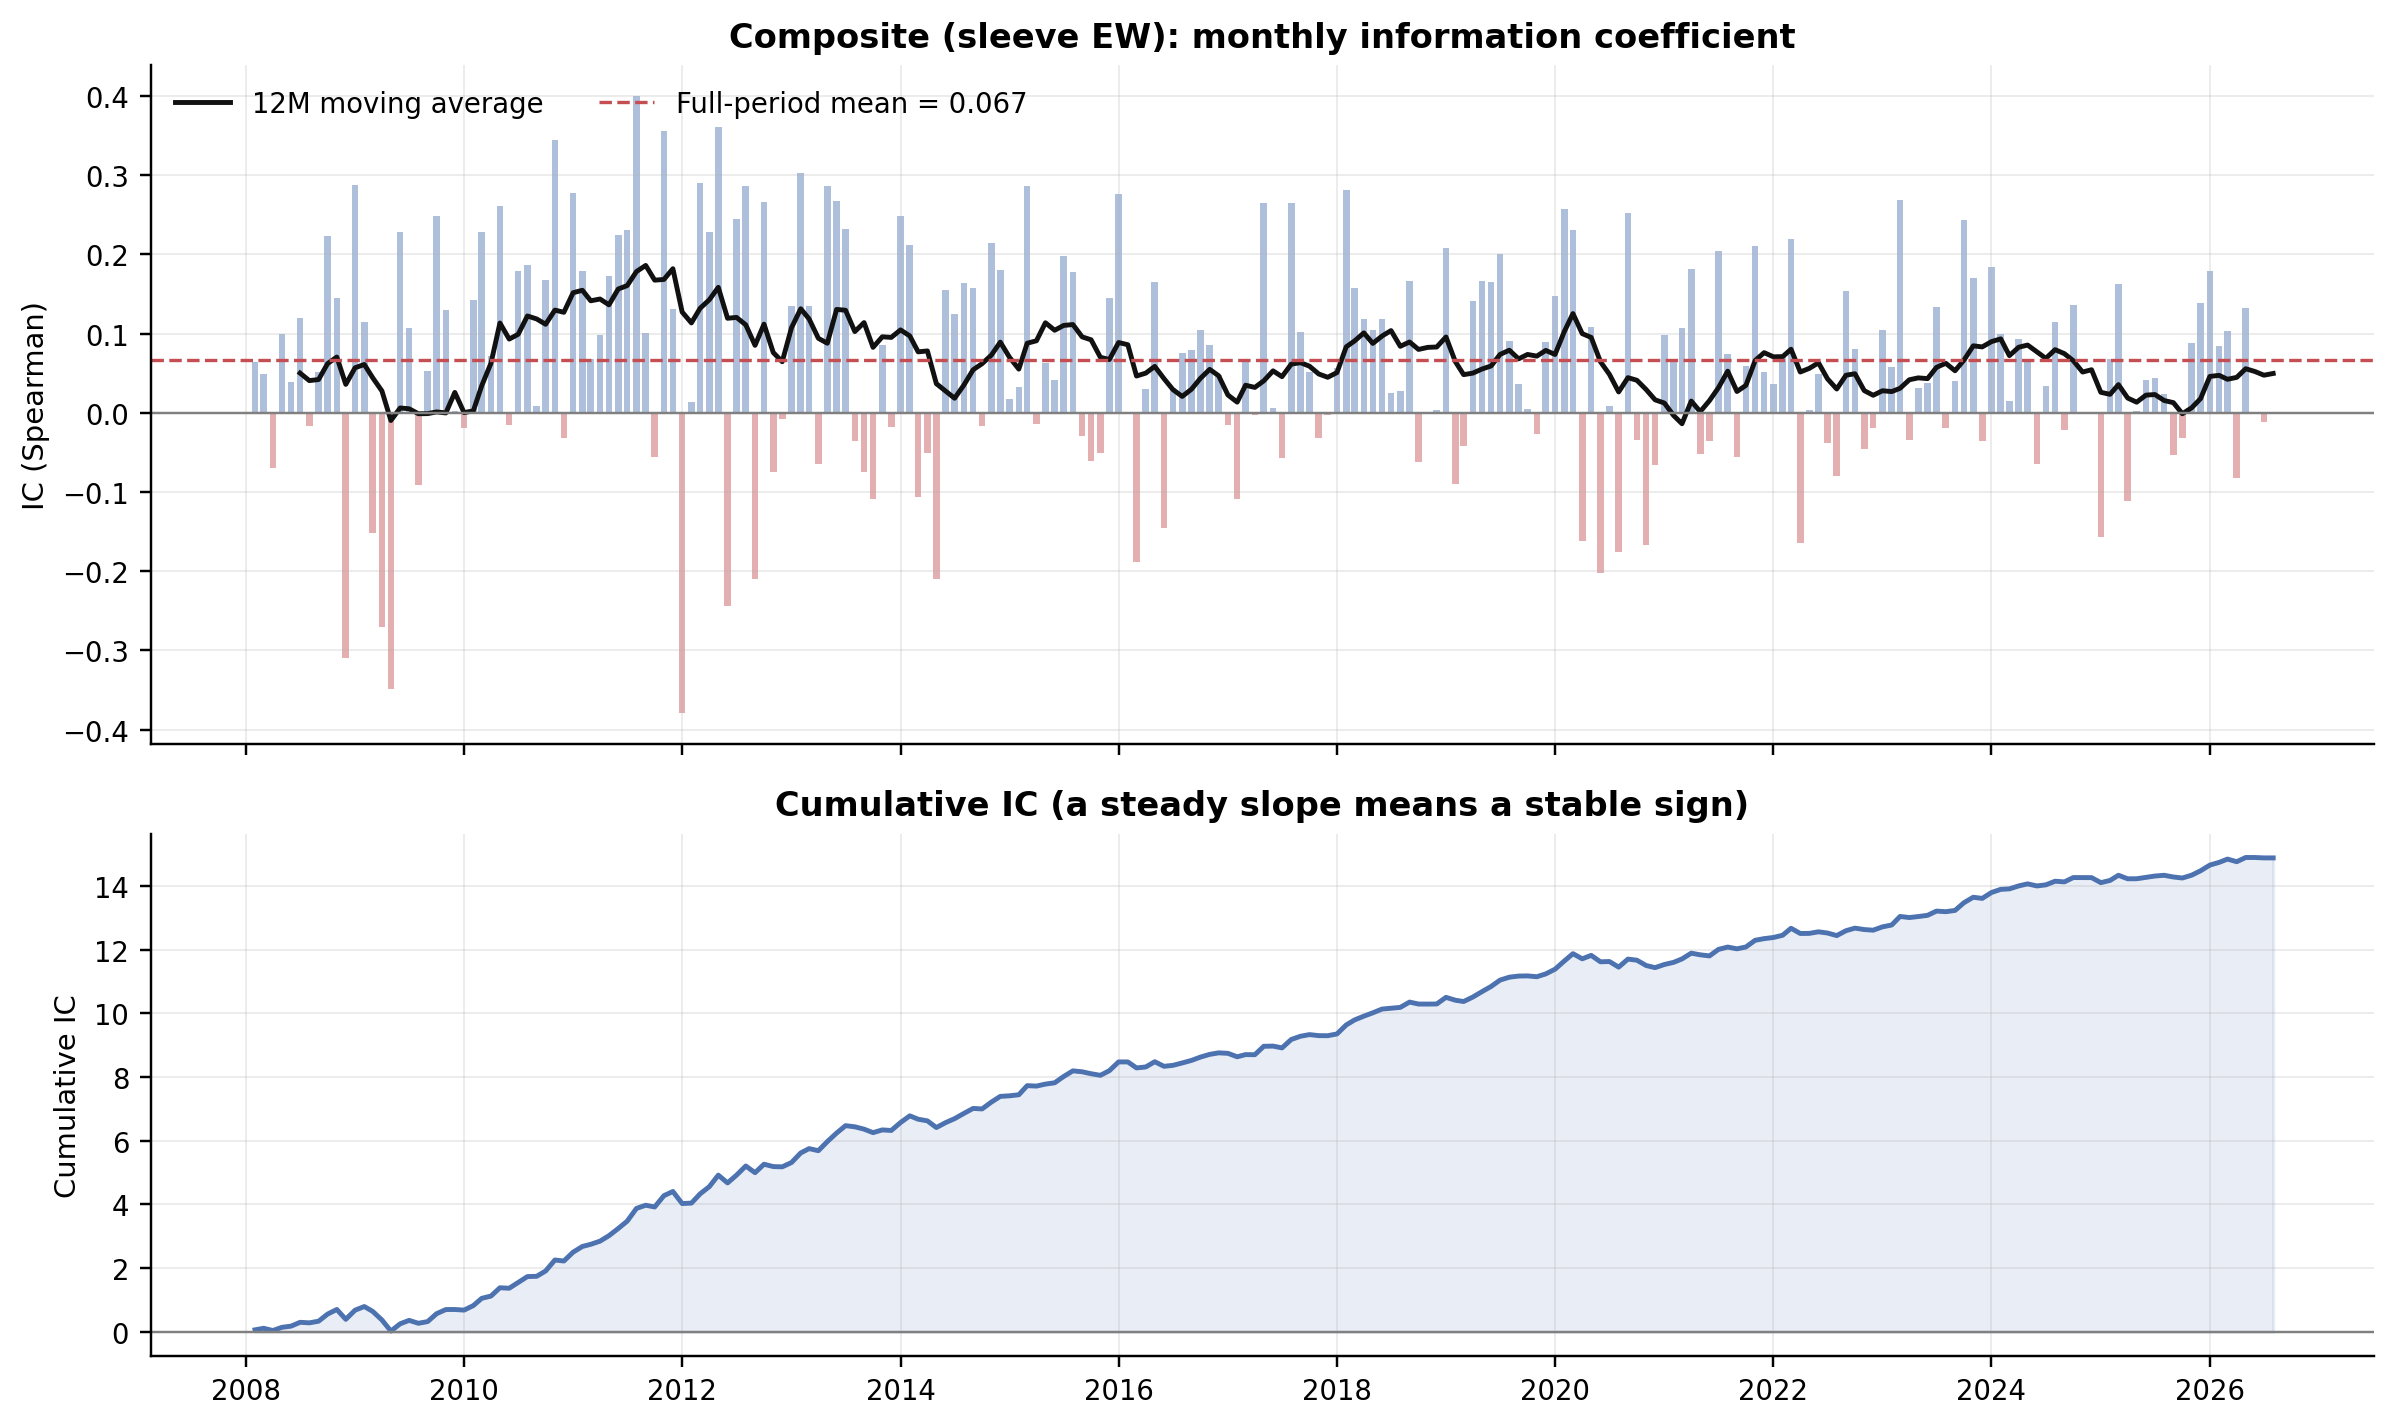

In [11]:
ic_comp = fl.ic.information_coefficient(panel, "comp_ew", "fwd_rtn")
fig = fl.plotting.plot_ic(ic_comp, ma_window=12, factor="Composite (sleeve EW)", method="Spearman")
fl.plotting.savefig(fig, f"{FIGDIR}/105_composite_ic_ts");

## 4. IS / OOS（ベースライン comp_ew の Q5 超過）

In [12]:
rows = {}
for c in ["comp_ew", "comp_flat", "comp_icir", "rev3p_ss"]:
    ex = res[c]["ew_excess"][f"Q{Q}"]
    for name, mask in [("IS 2008-2018", ex.index < OOS_SPLIT), ("OOS 2019-", ex.index >= OOS_SPLIT)]:
        s = fl.metrics.summarize(ex[mask])
        rows[(c, name)] = {"ann_excess_arith": s["mean_monthly"] * 12, "te": s["ann_vol"],
                           "IR": s["mean_monthly"] * 12 / s["ann_vol"], "t_NW": s["t_stat_NW"],
                           "hit": s["hit_ratio"]}
pd.DataFrame(rows).T

ann_excess_arith     te     IR   t_NW    hit
comp_ew   IS 2008-2018            0.1060 0.0895 1.1846 4.2655 0.6667
          OOS 2019-               0.1059 0.1108 0.9554 2.9829 0.5556
comp_flat IS 2008-2018            0.1100 0.0889 1.2380 4.0578 0.6364
          OOS 2019-               0.0735 0.1023 0.7189 2.3957 0.5333
comp_icir IS 2008-2018            0.0911 0.0858 1.0619 3.6350 0.6288
          OOS 2019-               0.0808 0.1009 0.8014 2.5594 0.5333
rev3p_ss  IS 2008-2018            0.0997 0.1092 0.9133 2.5513 0.5985
          OOS 2019-               0.0868 0.1117 0.7771 2.5785 0.6111

## 5. スリーブの中身: 素材12本の個別パフォーマンス

各素材を**合成に入るのと同じ形**（size+sector 中立 Blom・符号調整済み = Q5 が「良い側」）で
個別評価する。スリーブ・合成と同じ物差しなので、どの素材が牽引/足を引っ張っているかが直接読める。

In [13]:
MEMBERS = [(sl, f, sgn) for sl, ms in SLEEVES.items() for f, sgn in ms]
for sl, f, sgn in MEMBERS:
    panel[f"{f}_adj"] = sgn * panel[f"{f}_ss"]

member_cols = {f: f"{f}_adj" for _, f, _ in MEMBERS}
member_groups = pd.Series({f: sl for sl, f, _ in MEMBERS}, name="style")

sb_m, res_m = fl.multi.factor_scoreboard(panel, member_cols, groups=member_groups,
                                         q=Q, weighting="ew")
sb_m[["style", "top_ann_excess", "top_te", "top_IR", "top_t_NW", "top_max_dd",
      "ls_ann_excess", "ls_t_NW", "mean_IC", "ICIR_ann", "top_turnover_ann", "coverage"]] \
    .sort_values(["style", "top_ann_excess"], ascending=[True, False])

,style,top_ann_excess,top_te,top_IR,top_t_NW,top_max_dd,ls_ann_excess,ls_t_NW,mean_IC,ICIR_ann,top_turnover_ann,coverage
rev3r,A_revision,0.0965,0.1083,0.8897,3.8185,-0.2081,0.1562,6.0937,0.0499,1.6593,4.2638,0.8879
rev3p,A_revision,0.0923,0.1100,0.8591,3.5509,-0.2247,0.1394,4.6301,0.0489,1.4948,4.2377,0.8879
rev1r,A_revision,0.0719,0.0927,0.7808,3.4758,-0.1885,0.1186,5.7307,0.0304,1.3405,8.6054,0.8981
rev1p,A_revision,0.0634,0.0944,0.7035,3.0295,-0.1847,0.1016,4.6996,0.0289,1.2211,8.5504,0.8981
cgo_gain,B_price,0.1012,0.1263,0.7536,3.6667,-0.2193,0.0880,3.3904,0.0264,0.7535,3.3820,0.5451
mom12_1,B_price,0.0467,0.1107,0.4367,1.8532,-0.3348,0.0799,2.0988,0.0448,1.0466,3.2079,0.9983
dp_act,D_discipline,0.0444,0.1003,0.5140,2.0990,-0.3461,0.1207,4.9631,0.0405,1.7371,1.5991,0.9995
doe,D_discipline,0.0408,0.0907,0.3979,1.7817,-0.2130,0.1036,3.3290,0.0476,1.4370,1.2051,0.9902
xfin_cf,D_discipline,0.0401,0.0862,0.4331,1.8600,-0.1777,0.0983,3.7922,0.0286,1.0812,1.4516,0.9860
xfin_sp,D_discipline,0.0376,0.1018,0.4335,1.8821,-0.2658,0.1020,4.9972,0.0239,1.2674,1.7577,0.9286


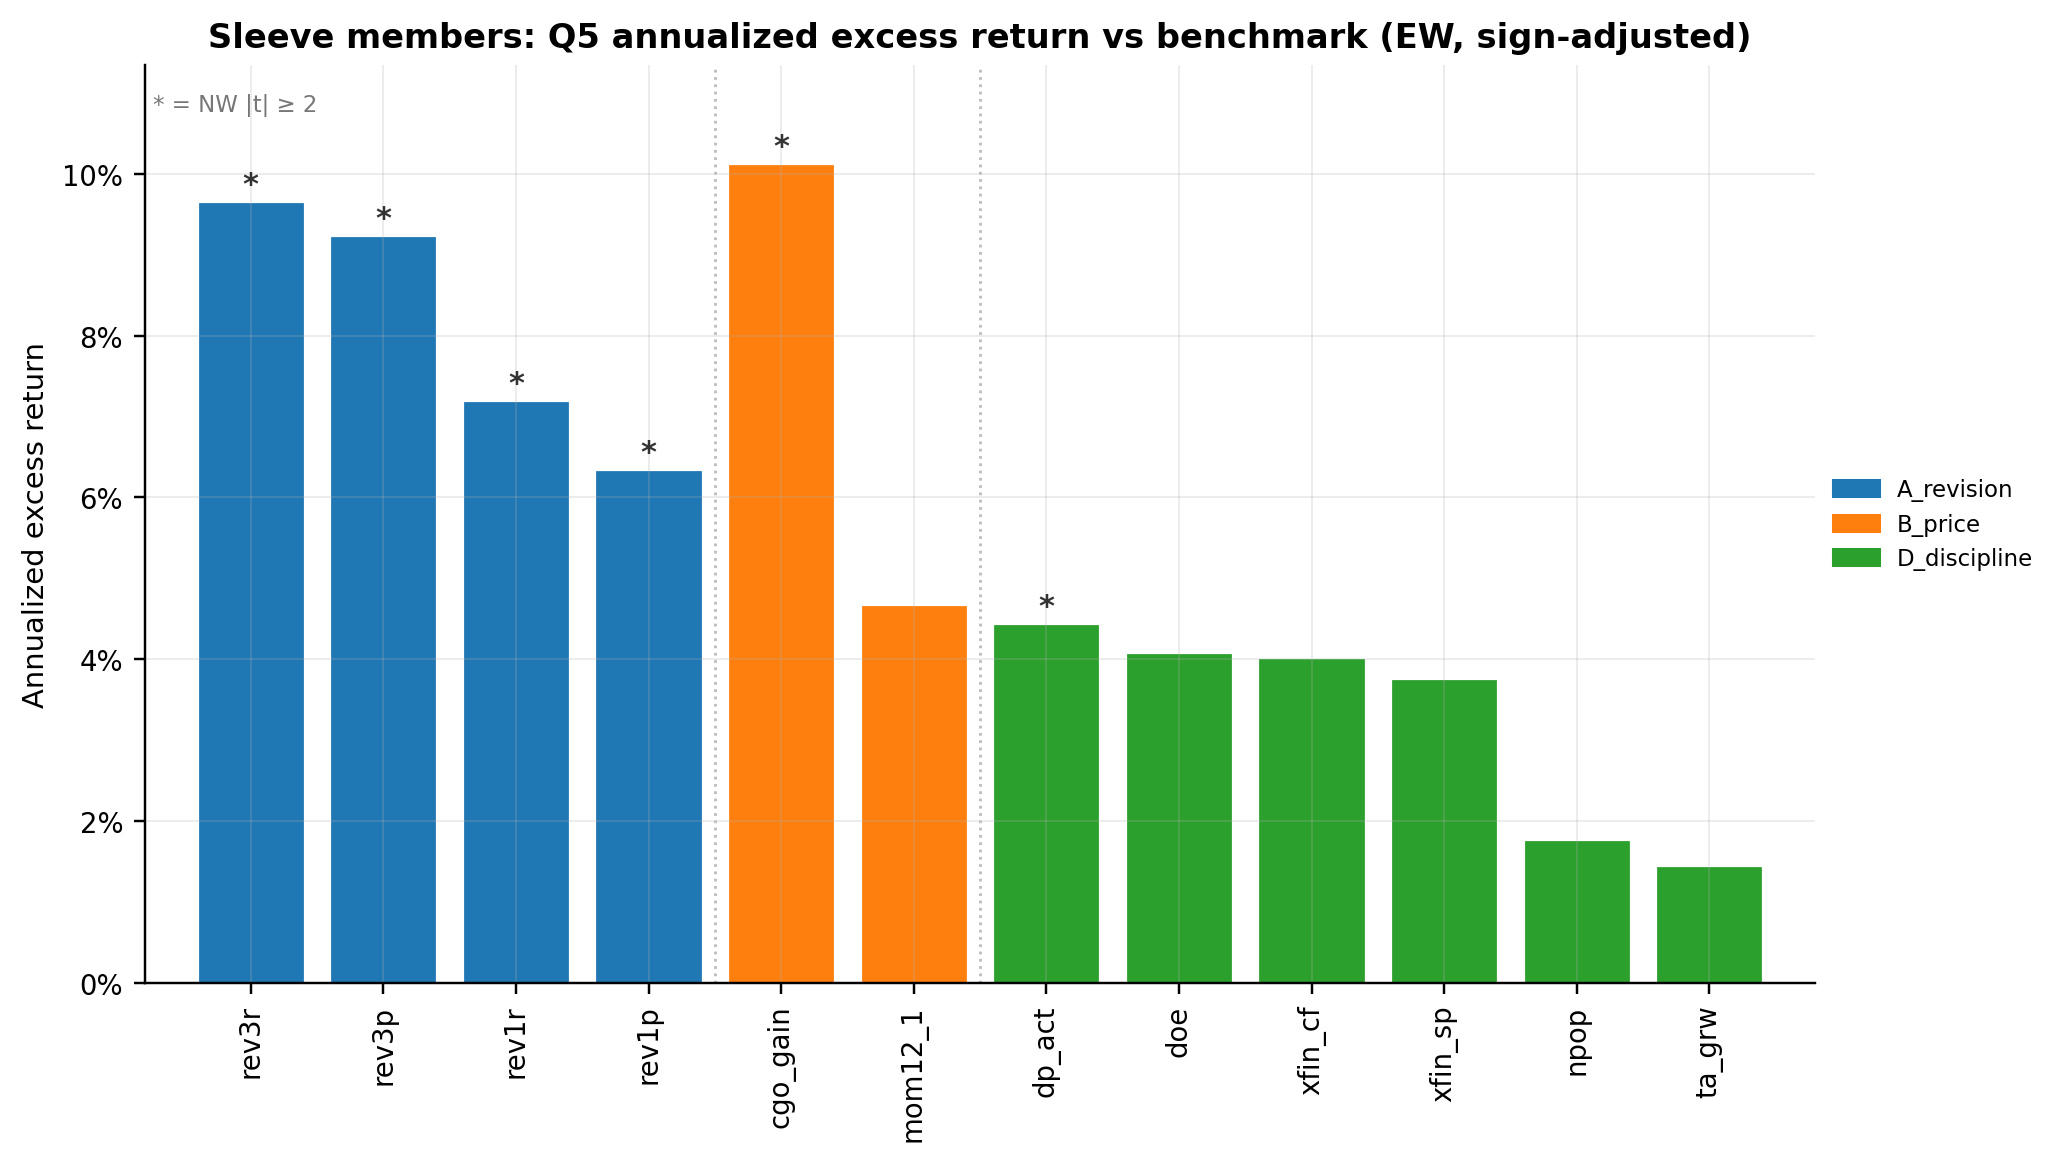

In [14]:
fig = fl.plotting.plot_scoreboard_bars(
    sb_m, value_col="top_ann_excess", tstat_col="top_t_NW",
    title=f"Sleeve members: Q{Q} annualized excess return vs benchmark (EW, sign-adjusted)")
fl.plotting.savefig(fig, f"{FIGDIR}/106_members_top");

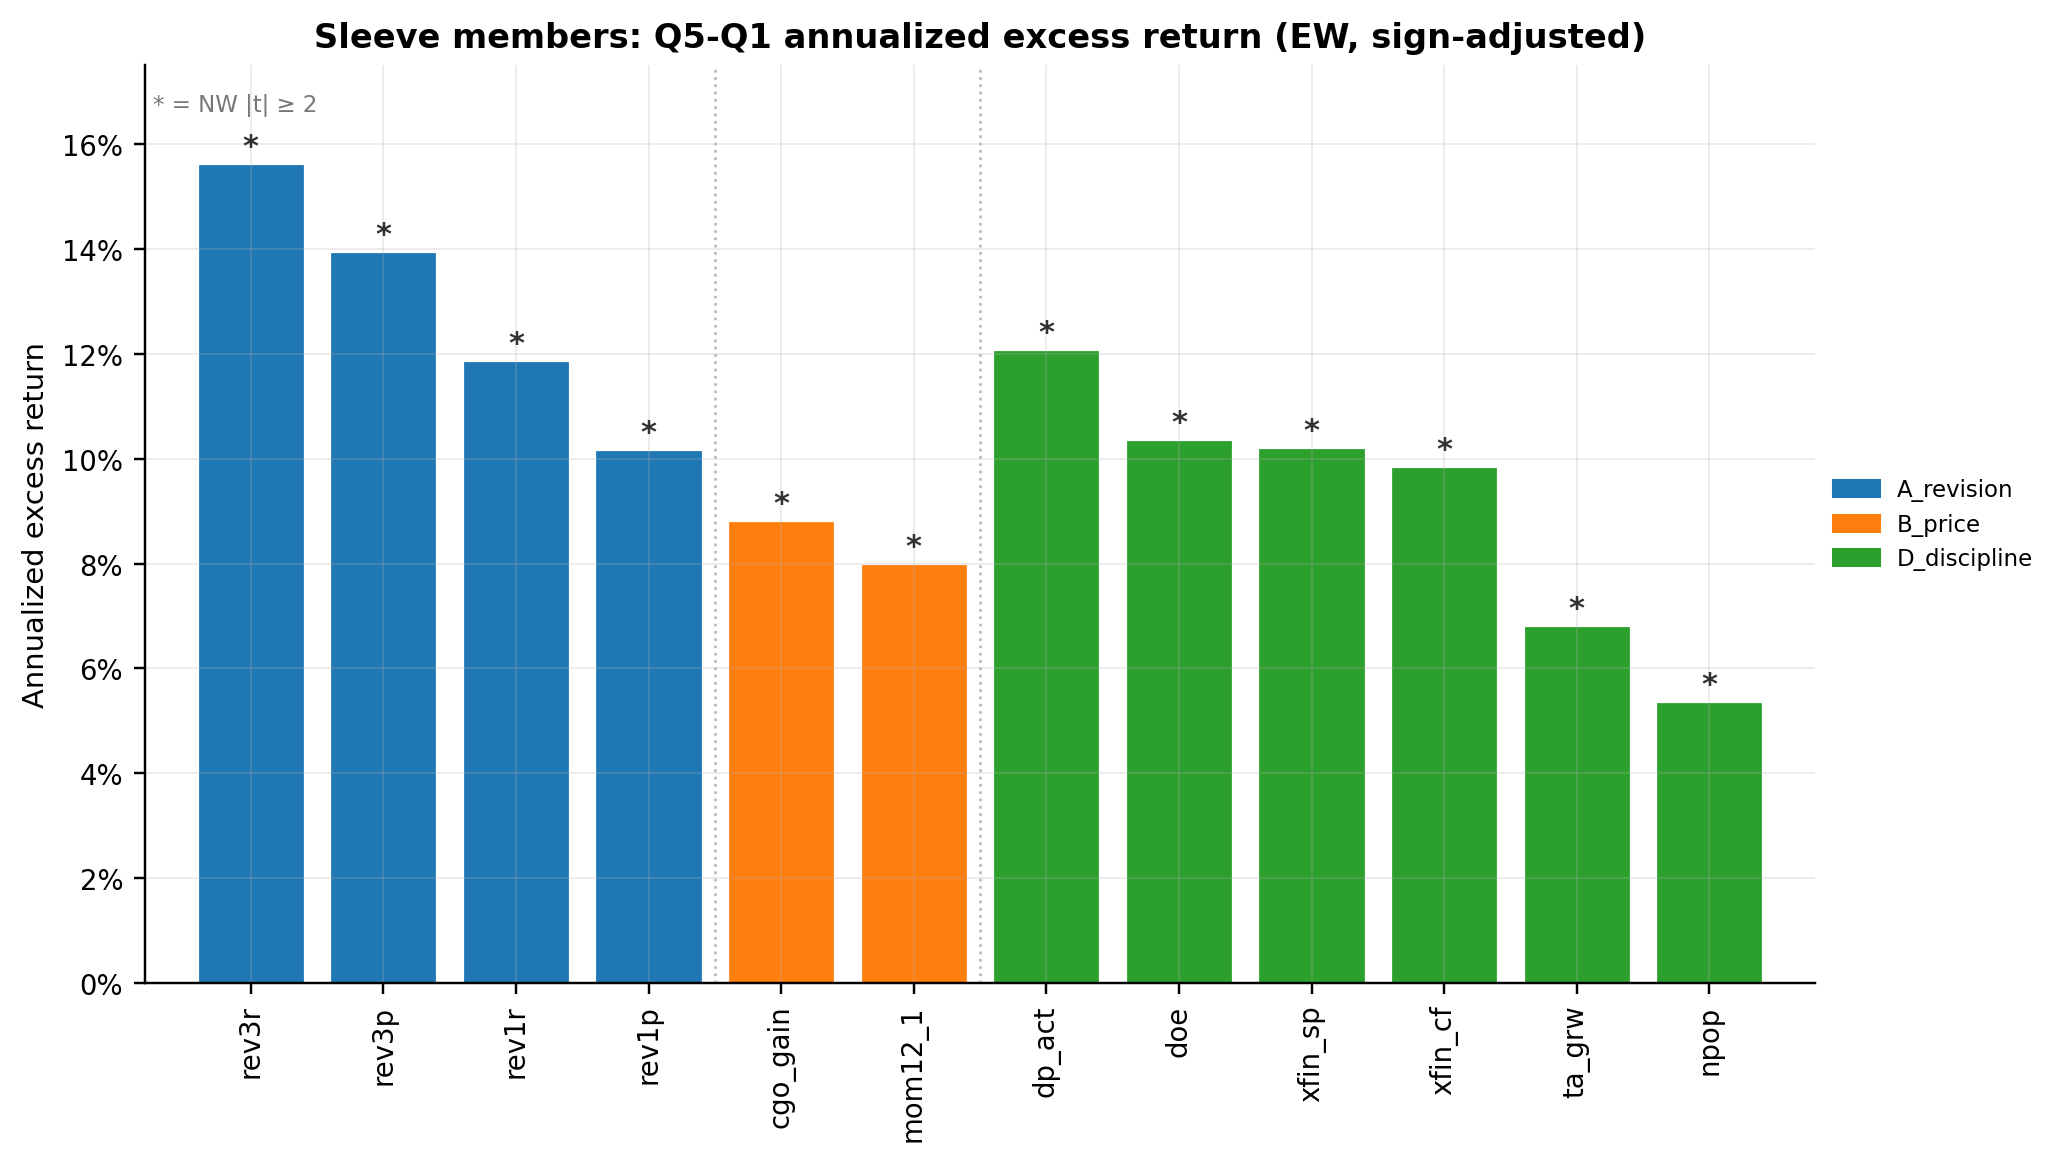

In [15]:
fig = fl.plotting.plot_scoreboard_bars(
    sb_m, value_col="ls_ann_excess", tstat_col="ls_t_NW",
    title=f"Sleeve members: Q{Q}-Q1 annualized excess return (EW, sign-adjusted)")
fl.plotting.savefig(fig, f"{FIGDIR}/107_members_ls");

/Users/inu/workspace/india/src/factorlab/multi.py:65: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(z, axis=0)
/Users/inu/workspace/india/.venv/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


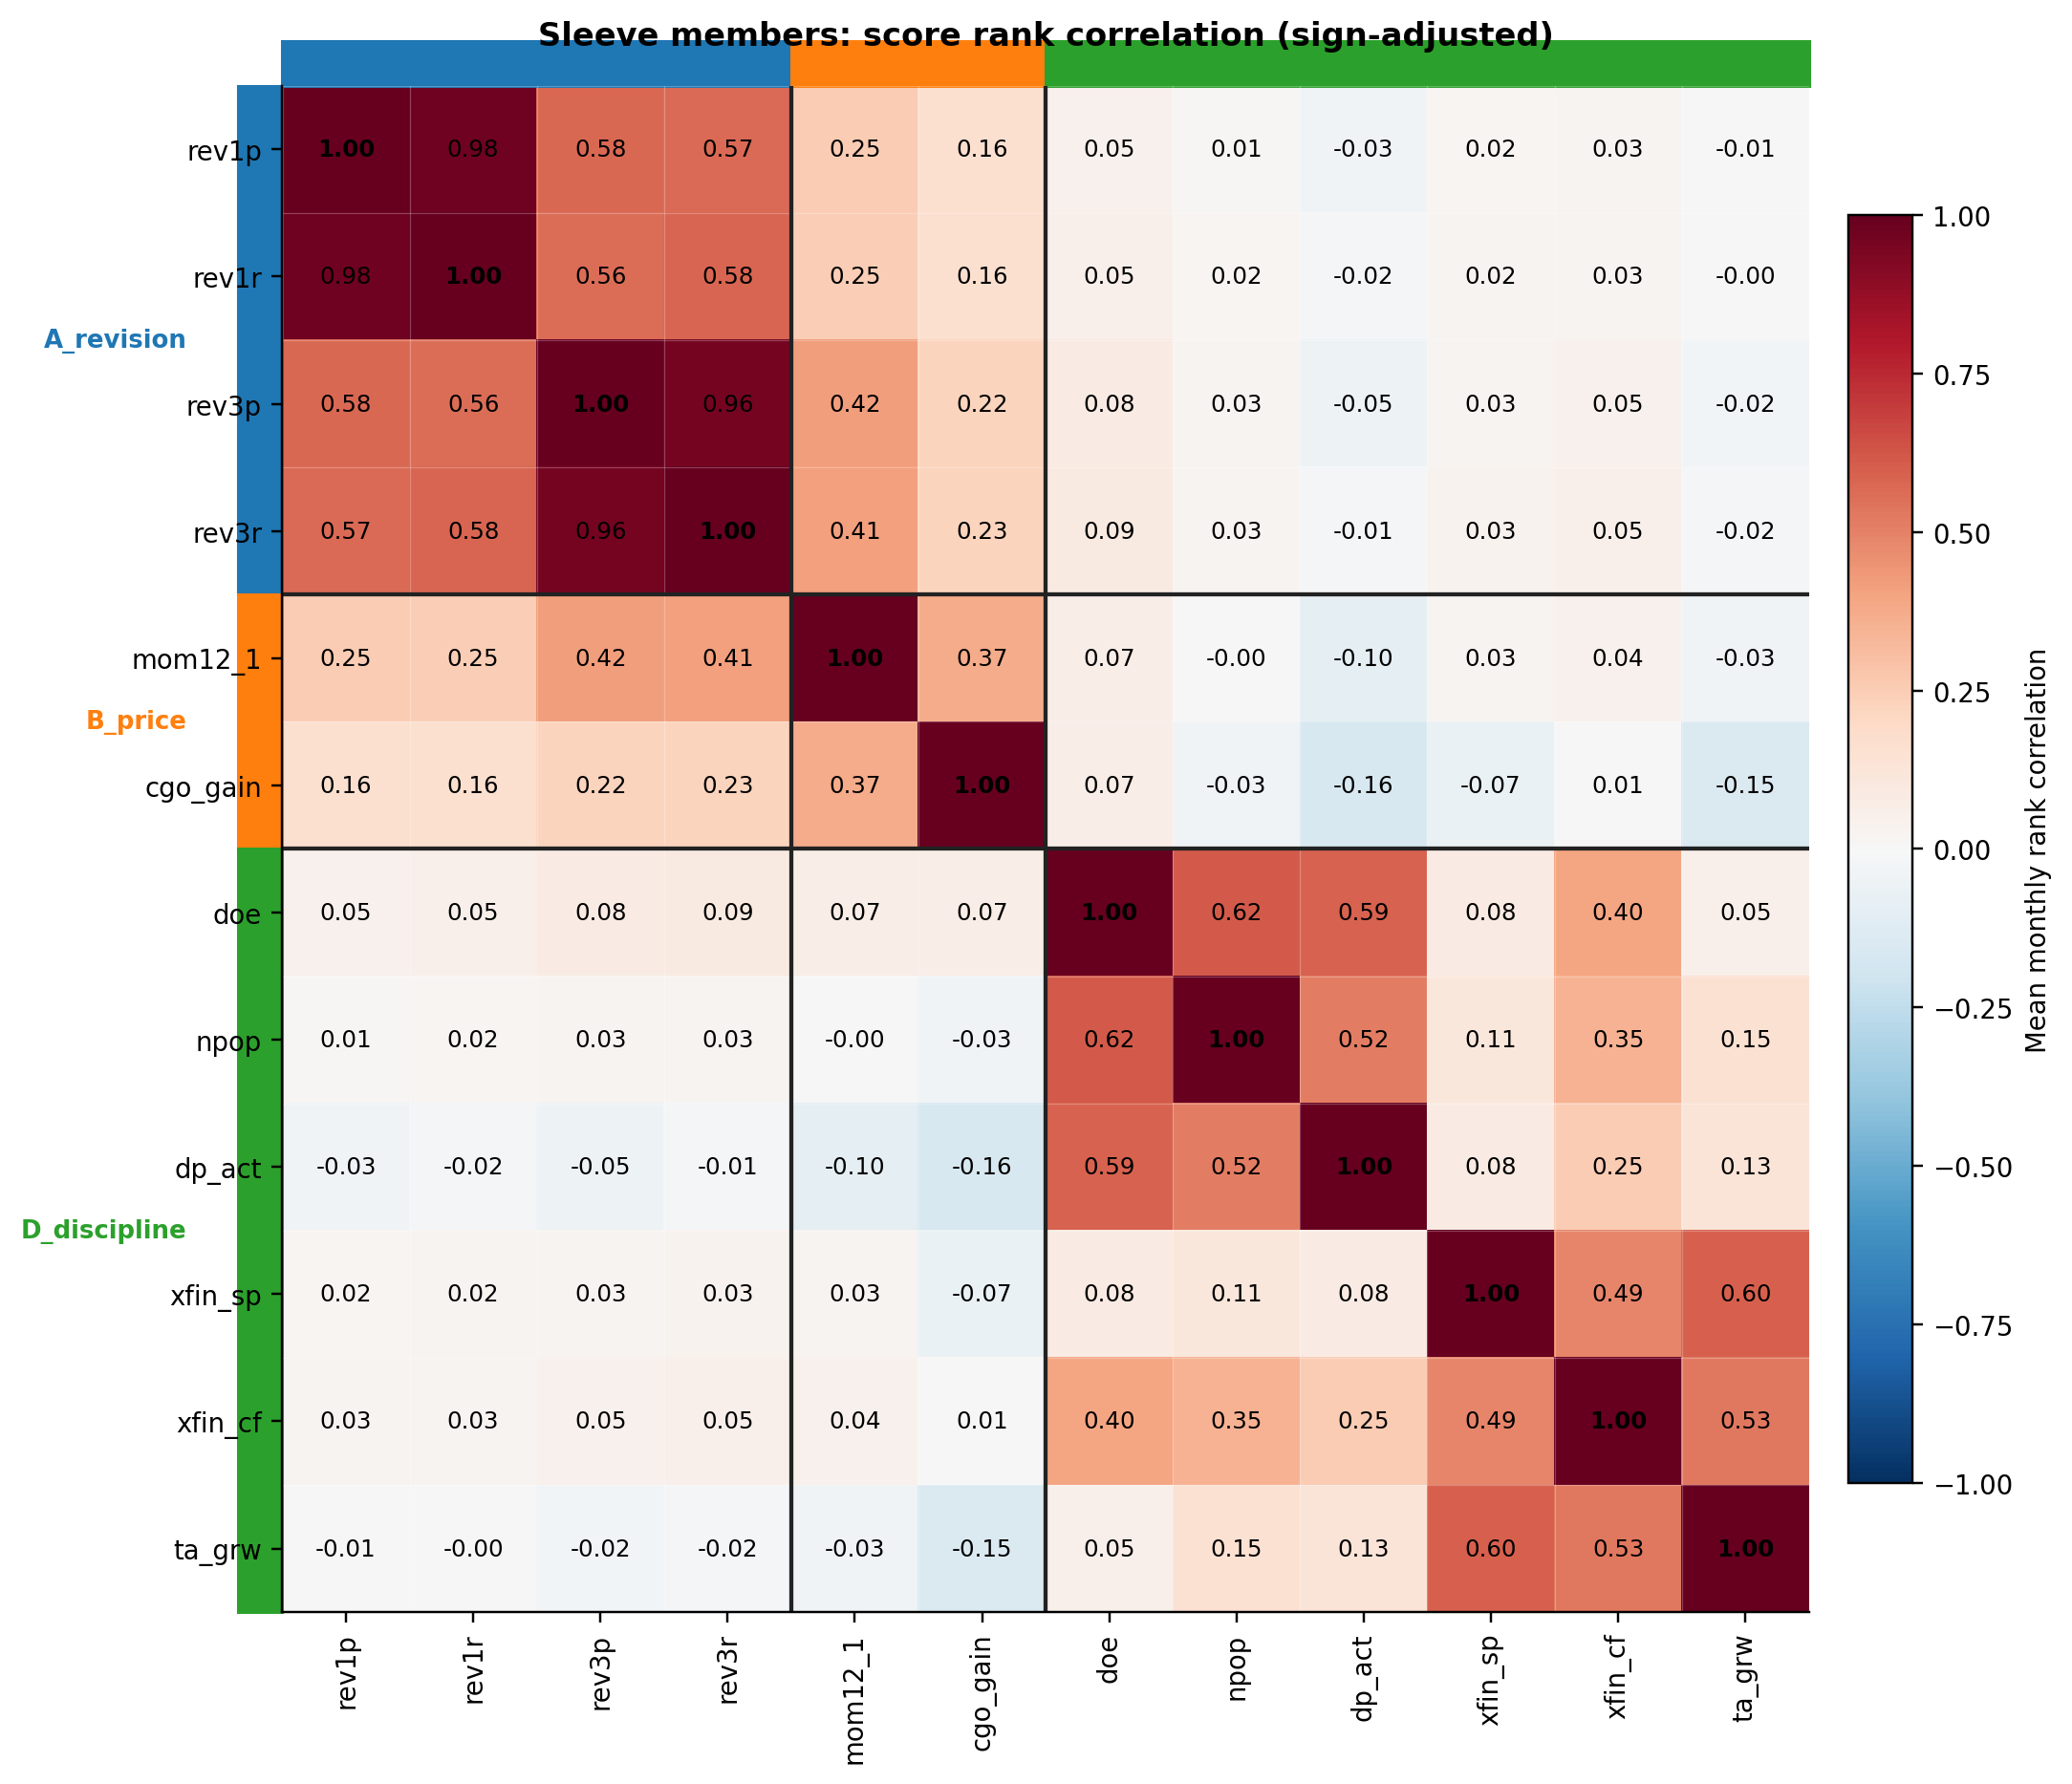

In [16]:
ordered = [f for sl, f, _ in MEMBERS]
corr_m = fl.multi.cross_sectional_corr(panel, [member_cols[f] for f in ordered], labels=ordered)
fig = fl.plotting.plot_factor_matrix(
    corr_m, groups=member_groups.reindex(ordered),
    title="Sleeve members: score rank correlation (sign-adjusted)",
    off_label="Mean monthly rank correlation", off_vmin=-1, off_vmax=1,
    annotate=True, off_fmt="{:.2f}", figsize=(10.5, 8.6))
fl.plotting.savefig(fig, f"{FIGDIR}/108_members_corr");

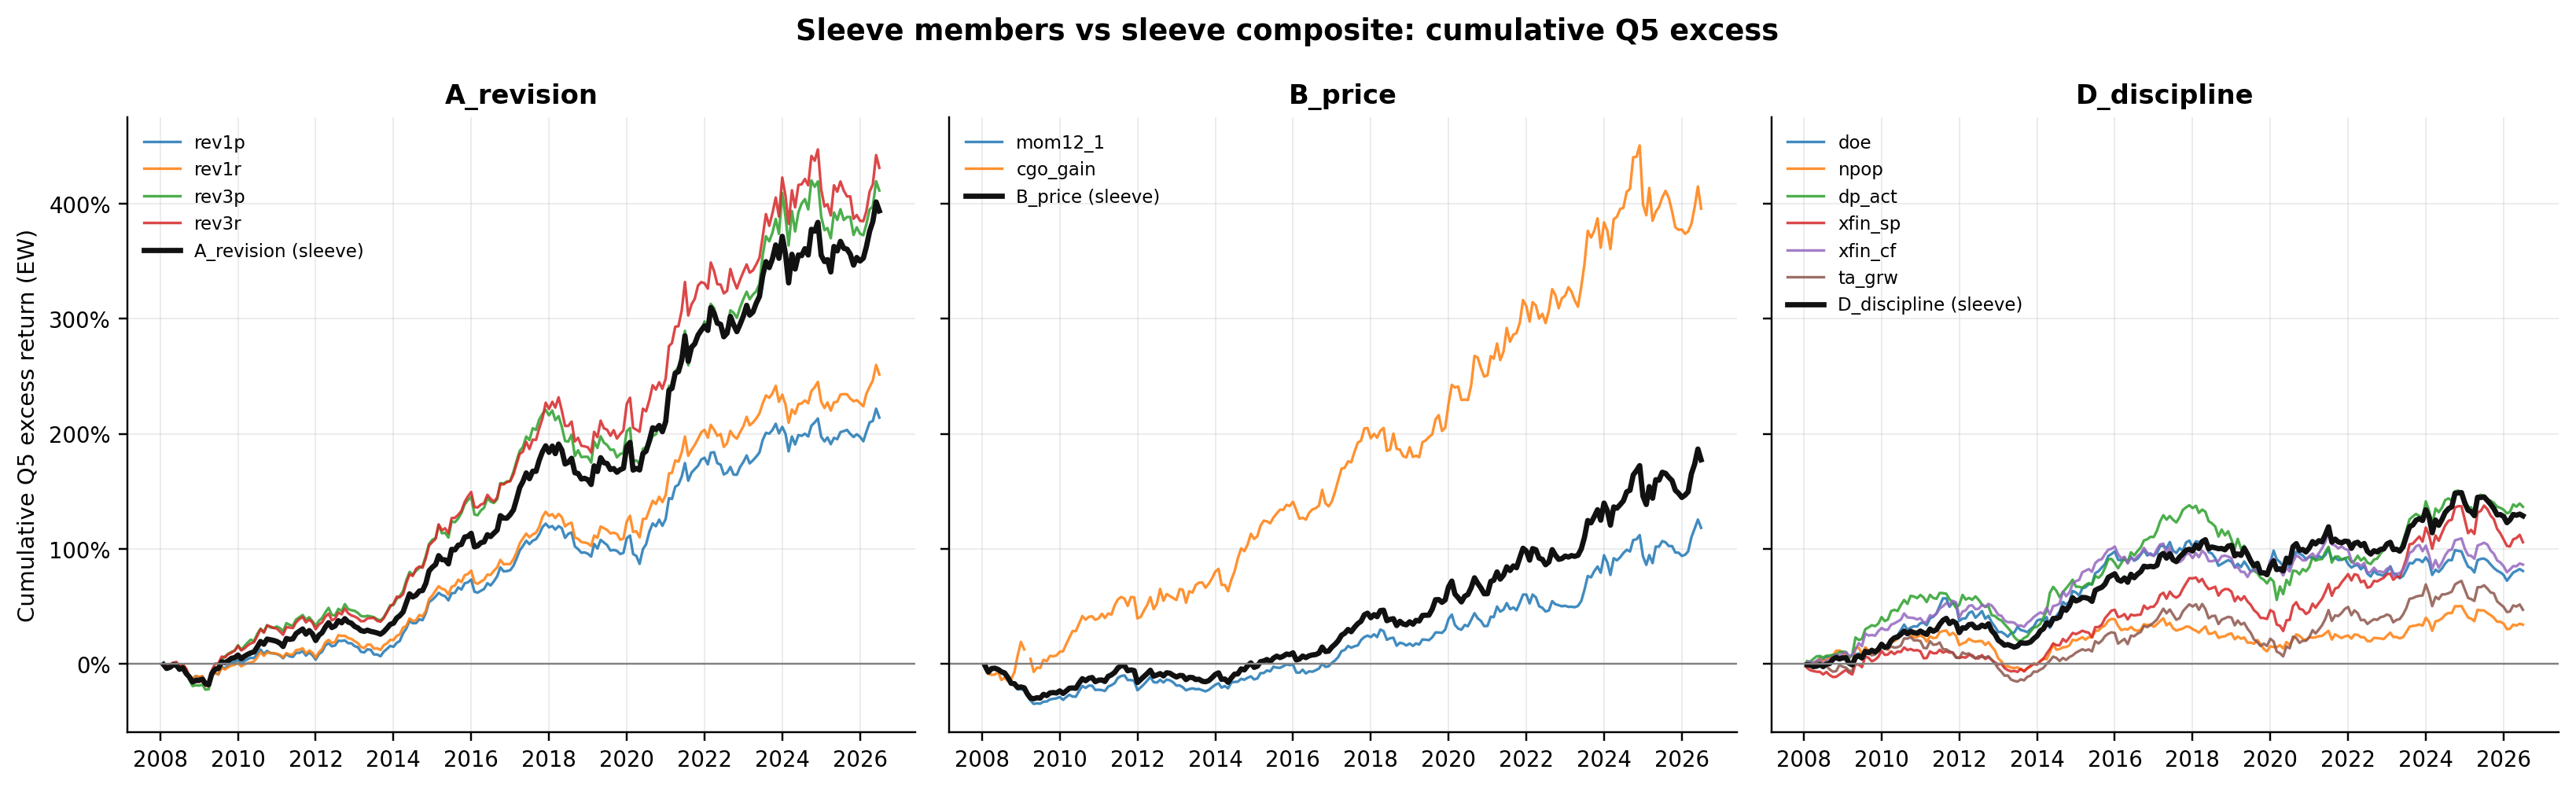

In [17]:
# スリーブ別: 素材とスリーブ合成の Q5 累積超過（EW）
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for ax, (sl, members) in zip(axes, SLEEVES.items()):
    for f, sgn in members:
        ex = res_m[f]["ew_excess"][f"Q{Q}"]
        ax.plot(fl.plotting.to_datetime_index(ex.index), (1 + ex).cumprod() - 1,
                linewidth=1.1, alpha=0.85, label=f)
    ex = res[sl]["ew_excess"][f"Q{Q}"]
    ax.plot(fl.plotting.to_datetime_index(ex.index), (1 + ex).cumprod() - 1,
            color="#111111", linewidth=2.2, label=f"{sl} (sleeve)")
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_title(sl)
    ax.legend(fontsize=7.5, loc="upper left")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.0f}%"))
axes[0].set_ylabel("Cumulative Q5 excess return (EW)")
fig.suptitle("Sleeve members vs sleeve composite: cumulative Q5 excess", fontweight="bold")
fig.tight_layout()
fl.plotting.savefig(fig, f"{FIGDIR}/109_members_q5_ts");

---

## 読みどころ

1. **合成 vs 最強単体（rev3p）**: 合成の狙いはリターンの上積みではなく
   **IR の改善と DD の浅さ**（分散効果）。Q5 の IR / max_dd_excess / turnover を比較
2. スリーブ相関（図100）が低いほど 2 段等ウェイトの意味がある
3. ICIR 加重が EW に勝つかは「スリーブの強さの持続性」次第。
   OOS で EW に劣るならウェイト推定はノイズ（EW 継続が結論）